# ONE-DIMENSIONAL FAIR AND PRIVATE REGRESSION- COMPARISON WITH XIAN ET AL. (2024)

**List the version of all the installed packages at the moment of compilation**

In [1]:
!pip freeze

absl-py==2.1.0
aiohttp==3.9.5
aiosignal==1.3.1
alembic==1.14.0
annotated-types==0.7.0
anyio==4.6.2.post1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.6.0
arrow==1.3.0
asttokens==2.4.1
astunparse==1.6.3
async-lru==2.0.4
async-timeout==4.0.3
attrs==24.2.0
autodp==0.2.3.1
Automat==20.2.0
babel==2.16.0
bcrypt==3.2.0
beautifulsoup4==4.12.3
beniget==0.4.1
bleach==4.1.0
blinker==1.4
cachetools==5.5.2
certifi==2020.6.20
certipy==0.2.1
cffi==1.17.1
chardet==4.0.0
charset-normalizer==3.4.0
chex==0.1.88
clarabel==0.11.1
click==8.0.3
cloud-init==25.1.4
cloudpickle==3.1.1
clu==0.0.12
colorama==0.4.4
comm==0.2.2
command-not-found==0.3
commonmark==0.9.1
configobj==5.0.6
constantly==15.1.0
contourpy==1.3.1
cryptography==3.4.8
cvxpy==1.7.1
cycler==0.12.1
Cython==3.0.10
dbus-python==1.2.18
debugpy==1.8.7
decorator==4.4.2
defusedxml==0.7.1
distrax==0.1.5
distro==1.7.0
distro-info==1.1+ubuntu0.2
dm-tree==0.1.8
docstring_parser==0.16
etils==1.11.0
exceptiongroup==1.2.2
executing==2.1.0


###  Import libraries and files

**Import libraries**

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import sklearn.linear_model
import math
from jax.random import PRNGKey, normal, split, uniform
from jax.flatten_util import ravel_pytree
import os
from typing import List, Dict, Tuple
from dataclasses import dataclass
import cvxpy as cp
import optax
from scipy.stats import ks_2samp

**Check if we are working on CPU/GPU**

In [3]:
device = jax.devices()[0]
print(device)

cuda:0


Import files: 

* **accountants.main**: DP-library, used to computed the moments accountant.
* **bias_measure_fcts**: measures of fairness, code from the article *https://arxiv.org/abs/1807.06362*
*  **ICML_aux**: auxiliar functions needed in the code

In [4]:
from accountants.main import create_accountant
from bias_measure_fcts import *
from aux_appendix import *

**Create folder to  save averaged results over seeds**

In [22]:
import os
import json

# Make sure the folder exists
os.makedirs("result_seeds", exist_ok=True)

### Define the functions required for the fair and private post-processing method of Xian et al. (2024)

In [102]:
@dataclass
class PostProcessResult:
    v_bins: np.ndarray
    mappings: Dict[int, np.ndarray]
    qa: Dict[int, np.ndarray]
    q: np.ndarray
    ptilde: Dict[int, np.ndarray]
    wtilde: Dict[int, float]


def discretize_range(y: np.ndarray, s: float, t: float, k: int):
    v = s + (np.arange(k) + 0.5) * (t - s) / k
    y_clip = np.clip(y, s, t)
    idx = np.argmin(np.abs(y_clip[:, None] - v[None, :]), axis=1)
    return v, idx


def isotonic_cdf_linf(qF: np.ndarray) -> np.ndarray:
    """
    L∞ isotonic regression for a private CDF as in Xian et al. (ICML 2024, Algorithm 1).
    Input:
        qF: scaled partial sums (cumulative sum of private histogram, normalized by group weight)
    Output:
        F: monotone CDF after L∞ isotonic regression
    """
    k = len(qF)
    F = np.zeros(k, dtype=float)

    for j in range(k - 1):
        best_val = -1e18
        best_l, best_r = 0, j
        # search all intervals [l, r] containing j
        for l in range(0, j + 1):
            for r in range(j, k - 1):
                diff = qF[l] - qF[r]  # L∞ criterion
                if diff > best_val:
                    best_val = diff
                    best_l, best_r = l, r
        # assign average of endpoints, clip to [0,1]
        F[j] = np.clip(0.5 * (qF[best_l] + qF[best_r]), 0.0, 1.0)

    F[-1] = 1.0  # last bin fixed to 1

    # enforce monotonicity just in case
    for j in range(1, k):
        if F[j] < F[j - 1]:
            F[j] = F[j - 1]

    return F


def private_histograms(yhat: np.ndarray, a: np.ndarray, groups: np.ndarray, k: int, s: float, t: float,
                        epsilon: float, seed: int):
    rng = np.random.default_rng(seed)
    v, idx = discretize_range(yhat, s, t, k)
    n = len(yhat)
    scale = 2.0 / (n * epsilon) if (epsilon is not None and epsilon > 0) else 0.0
    p_hat = {int(g): np.zeros(k, dtype=float) for g in range(len(groups))}
    for g in range(len(groups)):
        mask = (a == g)
        counts = np.bincount(idx[mask], minlength=k).astype(float) / n
        p_hat[g] = counts
    p_check = {g: (p_hat[g] + rng.laplace(0.0, scale, size=k)) for g in p_hat}
    ptilde = {}
    wtilde = {}
    for g in p_check:
        w = max(p_check[g].sum(), 0.0)
        wtilde[g] = w
        if w <= 0:
            pc = np.zeros(k); pc[-1] = 1.0; ptilde[g] = pc; continue
        qF = np.cumsum(p_check[g]) / w
        F = isotonic_cdf_linf(qF)
        p = np.diff(np.concatenate([[0.0], F]))
        p = np.clip(p, 0.0, None)
        ssum = p.sum()
        if ssum <= 0:
            p = np.zeros(k); p[-1] = 1.0
        else:
            p /= ssum
        ptilde[g] = p
    return v, ptilde, wtilde


def solve_barycenter_lp(v, ptilde, wtilde, alpha):
    groups = sorted(ptilde.keys())
    k = len(v)
    q = cp.Variable(k, nonneg=True)
    qa = {g: cp.Variable(k, nonneg=True) for g in groups}
    Pi = {g: cp.Variable((k, k), nonneg=True) for g in groups}

    cons = [cp.sum(q) == 1]
    for g in groups:
        cons += [cp.sum(Pi[g], axis=1) == ptilde[g]]
        cons += [cp.sum(Pi[g], axis=0) == qa[g]]
        cons += [cp.sum(qa[g]) == 1]
        for j in range(k):
            cons += [cp.sum(qa[g][:j+1] - q[:j+1]) <= alpha/2]
            cons += [-cp.sum(qa[g][:j+1] - q[:j+1]) <= alpha/2]
    V = (v[:, None] - v[None, :]) ** 2
    obj = 0
    for g in groups:
        obj += float(wtilde[g]) * cp.sum(cp.multiply(V, Pi[g]))
    prob = cp.Problem(cp.Minimize(obj), cons)
    prob.solve(solver=cp.SCS, verbose=False)
    if prob.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
        raise RuntimeError(f"LP status {prob.status}")
    qv = np.array(q.value).clip(min=0); qv /= qv.sum()
    qa_v = {g: np.array(qa[g].value).clip(min=0) for g in groups}
    for g in groups:
        ssum = qa_v[g].sum(); qa_v[g] = qa_v[g]/ssum if ssum>0 else np.eye(1, k, k-1).A1
    Pi_v = {g: np.array(Pi[g].value).clip(min=0) for g in groups}
    return qv, qa_v, Pi_v


def postprocess_predictions(yhat_train, a_train, groups, k, s, t, eps_post, alpha, seed=0):
    v, ptilde, wtilde = private_histograms(yhat_train, a_train, groups, k, s, t, eps_post, seed)
    q, qa, Pi = solve_barycenter_lp(v, ptilde, wtilde, alpha)
    return PostProcessResult(v_bins=v, mappings=Pi, qa=qa, q=q, ptilde=ptilde, wtilde=wtilde)


def apply_postprocess(yhat, a, res: PostProcessResult):
    v = res.v_bins; k = len(v)
    idx = np.argmin(np.abs(yhat[:, None] - v[None, :]), axis=1)
    rng = np.random.default_rng(0)
    out = np.array(yhat, copy=True)
    for g in res.mappings:
        mask = (a == g)
        if not np.any(mask):
            continue
        Pi = res.mappings[g]
        p_j = res.ptilde[g]
        probs = Pi / np.maximum(p_j[:, None], 1e-12)
        probs = probs / np.maximum(probs.sum(axis=1, keepdims=True), 1e-12)
        rows = idx[mask]
        sampled = np.fromiter((rng.choice(k, p=probs[j]) for j in rows), dtype=int, count=len(rows))
        out[mask] = v[sampled]
    return out

def expectation_apply_postprocess(yhat, a, res: PostProcessResult):  # USED ONLY FOR VERIFICATIONS
    """
    Deterministic postprocessing applied on discretized histograms.
    
    Returns postprocessed histograms for each group.
    
    yhat: predictions
    a: group labels
    res: PostProcessResult containing v_bins, ptilde, and Pi
    """
    v_bins = res.v_bins
    k = len(v_bins)
    groups = np.unique(a)
    
    # Step 1: compute discretized histograms for each group
    histograms = {}
    for g in groups:
        mask = (a == g)
        if np.any(mask):
            idx = np.argmin(np.abs(yhat[mask, None] - v_bins[None, :]), axis=1)
            hist = np.bincount(idx, minlength=k).astype(float)
            hist /= hist.sum()  # normalize to sum=1
            histograms[g] = hist
        else:
            histograms[g] = np.zeros(k)
    
    # Step 2: construct deterministic postprocessing matrices for each group
    postprocess_matrices = {}
    for g in res.mappings:
        Pi_g = res.mappings[g]     # k x k transport matrix
        p_g = res.ptilde[g]        # group histogram used in LP
        G = np.zeros((k, k))
        for i in range(k):
            if p_g[i] > 1e-12:
                G[i, :] = Pi_g[i, :] / p_g[i]
            else:
                G[i, i] = 1.0
        postprocess_matrices[g] = G
    
    # Step 3: multiply discretized histograms by postprocessing matrices
    postprocessed_histograms = {}
    for g in groups:
        H = histograms[g]           # original discretized histogram
        G = postprocess_matrices[g] # deterministic mapping
        postprocessed_histograms[g] = H @ G  # expected postprocessed histogram
    
    return postprocessed_histograms

def ks_distance(x: np.ndarray, y: np.ndarray, s: float, t: float, k: int):
    """
    Compute KS distance between two samples x and y,
    using the same discretization scheme as in private_histograms.
    """
    # get discretization bins and indices
    v, idx_x = discretize_range(x, s, t, k)
    _, idx_y = discretize_range(y, s, t, k)  # same v, just to be explicit

    # empirical histograms
    n_x, n_y = len(x), len(y)
    counts_x = np.bincount(idx_x, minlength=k).astype(float) / n_x
    counts_y = np.bincount(idx_y, minlength=k).astype(float) / n_y

    # empirical CDFs
    cdf_x = np.cumsum(counts_x)
    cdf_y = np.cumsum(counts_y)

    # KS statistic
    ks = np.max(np.abs(cdf_x - cdf_y))
    return ks



### Simple example of the above functions for fair and private post-processing with toy data

**Create toy data**

In [103]:
n = 1000
np.random.seed(0)

# Two groups: group 0 has predictions near 0, group 1 near 1
yhat_train = np.concatenate([
    np.random.normal(0.1, 0.05, n),   # group 0
    np.random.normal(0.9, 0.05, n)    # group 1
])
a_train = np.concatenate([
    np.zeros(n, dtype=int),
    np.ones(n, dtype=int)
])

yhat_test = np.concatenate([
    np.random.normal(0.1, 0.05, n),   # group 0
    np.random.normal(0.9, 0.05, n)    # group 1
])
a_test = np.concatenate([
    np.zeros(n, dtype=int),
    np.ones(n, dtype=int)
])
groups = np.array([0, 1])

**Step by step analysis of the fair and private post-processing method**

In [104]:
k = 10         # bins
s, t = 0.0, 1.0
eps_post = 1
alpha = 0.1
seed = 0

v0, ptilde0, wtilde0 = private_histograms(yhat_train, a_train, groups, k, s, t, 0, seed)
print("Discretized histograms per group:")
for g in groups:
    print(f"Group {g}: {ptilde0[g].round(3)}")

v, ptilde, wtilde = private_histograms(yhat_train, a_train, groups, k, s, t, eps_post, seed)

print("\nPrivate histograms per group:")
for g in groups:
    print(f"Group {g}: {ptilde[g].round(3)}")

res = postprocess_predictions(yhat_train, a_train, groups, k, s, t, eps_post, alpha, seed)

print("\nGenralized Barycenter q:", res.q.round(3))
print("\nGeneralized group barycenters qa:")
for g in groups:
    print(f"Group {g}: {res.qa[g].round(3)}")

# -------------------------
# Apply deterministic postprocessing to compute the expected value of the KS distance
# -------------------------
#yhat_test = yhat_train
#a_test = a_train

print("\n1) CHECK THAT THE IF WE POST-PROCESS THE TRAIN DATA, THE EXPECTED VALUE (W.R.T. THE MAPPING RANDOMNESS) OF KS IS ALPHA")
print("(this is exact only if epsilon=0)")


yhat_post = expectation_apply_postprocess(yhat_train, a_train, res)

# Split postprocessed predictions by group
yhat_post_group0 = yhat_post[0]
yhat_post_group1 = yhat_post[1]

print("\nExpectation (w.r.t mapping) of the histogram of postprocessed predictions by group:")
print("Group 0:", np.round(yhat_post_group0, 3))
print("Group 1:", np.round(yhat_post_group1, 3))

# -------------------------
# Compute expected  KS distance
# -------------------------
ks_value = np.max(np.cumsum(yhat_post_group0)-np.cumsum(yhat_post_group1))
print("\nExpectation (w.r.t mapping) of the KS distance between postprocessed groups:", ks_value.round(5))

print("\n2) KS DISTANCE FOR THE POST-PROCESSED TEST SAMPLE")


# -------------------------
# Postprocess the test sample
# -------------------------

yhat_post = apply_postprocess(yhat_test, a_test, res)

v1, ptilde1, wtilde1 = private_histograms(yhat_post, a_test, groups, k, s, t, 0, seed)
print("\nDiscretized sample post-processed histograms per group:")
for g in groups:
    print(f"Group {g}: {ptilde1[g].round(3)}")

# Split postprocessed predictions by group
yhat_post_group0 = yhat_post[a_test==0]
yhat_post_group1 = yhat_post[a_test==1]

# -------------------------
# Compute KS distance between the postprocessed groups
# -------------------------
ks_value = ks_distance(yhat_post_group0, yhat_post_group1, s, t, k)
ks_stat, _ = ks_2samp(yhat_post_group0, yhat_post_group1)

print("\nSample KS distance between discretized postprocessed groups:", ks_value.round(3))
print("Sample KS distance between postprocessed groups:", ks_stat.round(3))

Discretized histograms per group:
Group 0: [0.524 0.453 0.023 0.    0.    0.    0.    0.    0.    0.   ]
Group 1: [0.    0.    0.    0.    0.    0.    0.    0.013 0.471 0.516]

Private histograms per group:
Group 0: [0.525 0.452 0.015 0.    0.001 0.002 0.    0.001 0.    0.004]
Group 1: [0.    0.    0.    0.    0.    0.    0.    0.004 0.475 0.521]

Genralized Barycenter q: [0.05  0.    0.    0.004 0.475 0.413 0.001 0.002 0.001 0.054]

Generalized group barycenters qa:
Group 0: [0.1   0.    0.    0.004 0.475 0.413 0.001 0.002 0.001 0.004]
Group 1: [0.    0.    0.    0.004 0.475 0.413 0.001 0.002 0.001 0.104]

1) CHECK THAT THE IF WE POST-PROCESS THE TRAIN DATA, THE EXPECTED VALUE (W.R.T. THE MAPPING RANDOMNESS) OF KS IS ALPHA
(this is exact only if epsilon=0)

Expectation (w.r.t mapping) of the histogram of postprocessed predictions by group:
Group 0: [0.1   0.    0.    0.004 0.474 0.422 0.    0.    0.    0.   ]
Group 1: [0.    0.    0.    0.013 0.471 0.409 0.001 0.002 0.001 0.103]

Expe

/home/david/.local/lib/python3.10/site-packages/scs/__init__.py:83: UserWarning: Converting A to a CSC (compressed sparse column) matrix; may take a while.
  warn(


**Plot of the post-processed test histograms**

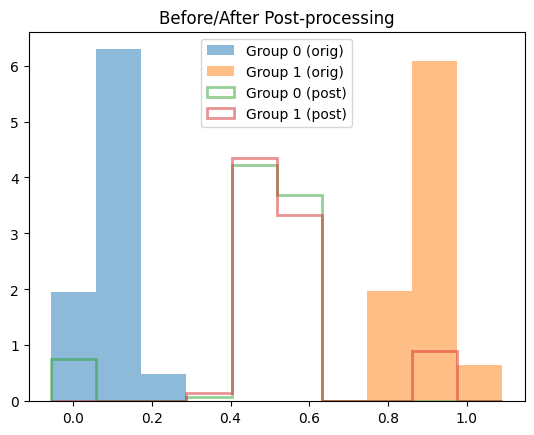

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Compute common bins over all data
all_data = np.concatenate([yhat_test[a_test==0], yhat_test[a_test==1],
                           yhat_post[a_test==0], yhat_post[a_test==1]])
bins = np.linspace(all_data.min(), all_data.max(), k+1)  # 10 bins

# Plot histograms with the same bins
plt.hist(yhat_test[a_test==0], bins=bins, alpha=0.5, label='Group 0 (orig)', density=True)
plt.hist(yhat_test[a_test==1], bins=bins, alpha=0.5, label='Group 1 (orig)', density=True)
plt.hist(yhat_post[a_test==0], bins=bins, alpha=0.5, label='Group 0 (post)', 
         density=True, histtype='step', linewidth=2)
plt.hist(yhat_post[a_test==1], bins=bins, alpha=0.5, label='Group 1 (post)', 
         density=True, histtype='step', linewidth=2)

plt.title("Before/After Post-processing")
plt.legend()
plt.show()


## COMPARISON WITH OUR APPROACH IN THE SIMULATED FAIRNESS DATASET

### Generate the exact same data as in the Fairness Section

In [146]:
# parameters
n = 30000              # total samples   
p = 0.7                # proportion of samples where Y = A
d_core   = 8           # dimension of core features
d_spurious = 8         # dimension of spurious features
s_core   = 0.2
s_spurious = 0.4

# Simulate train data 
random_seed = 46 #   TO REPEAT THE PAPER RESULT, AVERAGE OVER THE RANDOM SEEDS 42,43,44,45,46  ----------------------- !!!!!!!
X, Y, Y_cont, A = fairness_data(n, p, d_core, d_spurious, s_core, s_spurious, random_state= random_seed)
Y_cont = Y_cont-1/2
Y_flat = Y_cont[:,0]+ Y_cont[:,1]

train_data = {"X": X, 
              "A": A,
              "Y": Y_flat, 
              "X0": X[A==0],
              "Y0": Y_flat[A==0],
              "X1": X[A==1], 
              "Y1": Y_flat[A==1], 
              "n0": int(jnp.sum(A==0)), 
              "n1": int(jnp.sum(A==1)) }

# Simulate test data
X_test, Y_test, Y_cont_test, A_test = fairness_data(n, p, d_core, d_spurious, s_core, s_spurious, random_state = 3)
Y_cont_test = Y_cont_test-1/2
Y_flat_test = Y_cont_test[:,0] + Y_cont_test[:,1]

test_data = {"X": X_test, 
              "A": A_test,
              "Y": Y_flat_test, 
              "X0": X_test[A_test==0],
              "Y0": Y_flat_test[A_test==0],
              "X1": X_test[A_test==1], 
              "Y1": Y_flat_test[A_test==1], 
              "n0": int(jnp.sum(A_test==0)), 
              "n1": int(jnp.sum(A_test==1)) }

**Plot the response variable Y by groups A=0 and A=1**

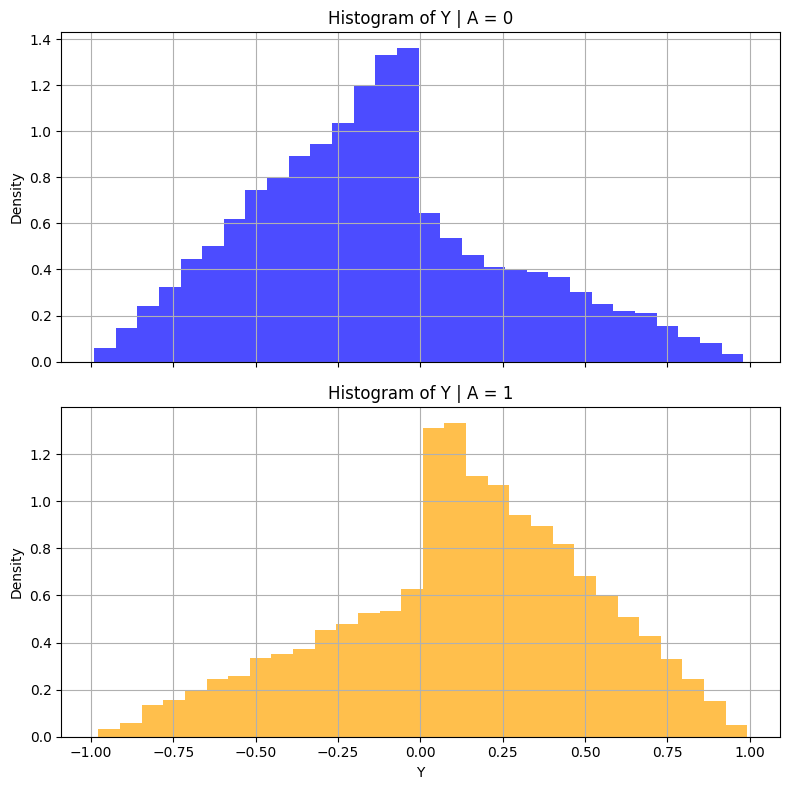

In [147]:
# Flatten Y0 and Y1 for plotting
Y0_flat = train_data["Y0"]
Y1_flat = train_data["Y1"]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Histogram for A = 0
axes[0].hist(Y0_flat, bins=30, alpha=0.7, color='blue', density=True)
axes[0].set_title('Histogram of Y | A = 0')
axes[0].set_ylabel('Density')
axes[0].grid(True)

# Histogram for A = 1
axes[1].hist(Y1_flat, bins=30, alpha=0.7, color='orange', density=True)
axes[1].set_title('Histogram of Y | A = 1')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Density')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Compute some values that will be used across all the examples to compute wasserstein distances. In particular the matrix $R=\{R_{i,j}\}_{i,j}$ which appears in the discrete formula for the one-dimensional Wasserstein distance only depends on the sample sizes considered. In our loss functions, we need to compute Wasserstein distances for samples of sizes

* $n_0$ and $n_1$  (to impose SP)
  
The function *R_and_indexes* computes this matrix in a sparse form: it returns a vector of indexes with values $(i,j)$ with $R_{i,j}>0$, and a vector with the values $R_{i,j}$ for such indexes.

In [148]:
R_vector, indexes = R_and_indexes(train_data["n0"],train_data["n1"])
R_vector_test, indexes_test = R_and_indexes(test_data["n0"],test_data["n1"])

####  Define the baseline model (fully connected NN)

In [149]:
class fully_connected:
    def __init__(self, key, input_dim):
        key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)
        self.params = {
            "linear1_w": xavier_uniform(key1, (input_dim,128)),    
            "linear1_b": jnp.zeros(128), 
            "linear2_w": xavier_uniform(key2, (128,1)),    
            "linear2_b": jnp.zeros(1), 
            #"linear3_w": xavier_uniform(key3, (512,2)),    
            #"linear3_b": jnp.zeros(2), 
        }

    def forward(self, x, params):
        # Compute logits and apply sigmoid for logistic regression
        x = jnp.dot(x, params["linear1_w"]) + params["linear1_b"]
        x = jax.nn.relu(x)
        x = jnp.dot(x, params["linear2_w"]) + params["linear2_b"]
        #x = jax.nn.relu(x)
        #x = jnp.dot(x, params["linear3_w"]) + params["linear3_b"]
        return x.reshape(-1)

    def penalized_layer(self, x, params):
        return self.forward(x, params)

**For the comparison, we are going to train:**

  -  **Baseline:** Model trained with DP-SGD under $(2,1/n)$-DP
  -  **Xian et al. (2024):** We consider the same model trained with DP-SGD under $(1,1/n)$-DP, and apply the fair and private postprocessing under $(1,0)$-DP for different values of the fairness regularization parameter $\alpha$ (see the original article, $\alpha$ represents the diameter of the KS balls around the generalized barycenter). By composition, the mechanism is $(2,1/n)$-DP.
  -  **Our approach:** Train the model with DP-SGD under $(2,1/n)$-DP, penalized with the squared wasserstein distance between conditional distributions. 

### Functions required for the optimization

**Define the regression mse loss and the private gradients (computed for each batch within smaller minibatches)**

In [150]:
def loss_mse(flat_params, unflatten_params, model, X, Y):
    Y_pred = model.forward(X, unflatten_params(flat_params))
    return jnp.mean( (Y_pred - Y)**2 )
    
def gradient_regression_loss(flat_params, unflatten_params, X_batch, Y_batch, model, C, minibatch_number = 10, parallel=True):
    # parallel = TRUE <- uses jax.vmap instead of a loop, faster but requires more memory.

    # Loss function: Binary Cross-Entropy
    def individual_mse_loss_flat(flat_params, unflatten_params, model, X, Y):
        Y_pred = model.forward(X, unflatten_params(flat_params))
        return (Y_pred - Y)**2 
        #return jnp.sqrt(jnp.sum( (Y_pred - Y)**2 , axis=1))
                
    jacobian_loss= jax.jacobian(individual_mse_loss_flat, argnums=0)
      
    def compute_gradient_classification_minibatch(flat_params, unflatten_params, X_minibatch, Y_minibatch, C):
        # Calcula el gradiente para el minibatch
        gradient_loss_flat_params = jacobian_loss(flat_params, unflatten_params, model, X_minibatch, Y_minibatch)
        gradient_loss_flat_params_clipped = clip_row_norms(gradient_loss_flat_params, C)
        gradient = gradient_loss_flat_params_clipped.mean(axis=0)
        return gradient
        
    batch_size = X_batch.shape[0]
    minibatch = batch_size//minibatch_number
    minibatch_limit = minibatch_limits(batch_size, minibatch)
    
    # Apply vmap over the minibatches
    vmap_gradients_loss = jax.vmap(compute_gradient_classification_minibatch, in_axes=(None, None, 0, 0, None))
    
    X_minibatch_array = jnp.array(jnp.split(X_batch, minibatch_limit, axis=0))
    Y_minibatch_array = jnp.array(jnp.split(Y_batch, minibatch_limit, axis=0))
    
    # Now compute the gradients for all minibatches
    if parallel == False:
        gradient_sum = 0
        for i in range(len(X_minibatch_array)):
            X_minibatch = X_minibatch_array[i]
            Y_minibatch = Y_minibatch_array[i]
            grad = compute_gradient_classification_minibatch(flat_params, unflatten_params, X_minibatch,Y_minibatch, C)
            gradient_sum += grad
        gradient_flat_params = gradient_sum / len(X_minibatch_array)
    else:
        gradient_flat_params = vmap_gradients_loss(flat_params, unflatten_params, X_minibatch_array,
                                               Y_minibatch_array, C).mean(axis=0)     
    return  gradient_flat_params

**Function to evaluate the results of the post-processed model**

In [151]:
def evaluate_postprocessing(yhat_test: np.ndarray, a_test: np.ndarray,
                            yhat_train: np.ndarray, a_train: np.ndarray,
                            y_true: np.ndarray,
                            groups: np.ndarray,
                            eps_post: float,
                            k_list: List[int],
                            interval: Tuple[float, float] = (-5.0, 5.0),
                            seed: int = 0) -> Dict[Tuple[int, float], Tuple[float, float]]:
    results = {}
    alpha_list = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
    k = k_list[0]
    for gamma in alpha_list:
        res = postprocess_predictions(yhat_train, a_train, groups,
                                        k=k, s=interval[0], t=interval[1],
                                        eps_post=eps_post, alpha=gamma, seed=seed)
        ypp = apply_postprocess(yhat_test, a_test, res)
        # Conditioned samples
        ypp0 = ypp[a_test==0]
        ypp1 = ypp[a_test==1]
        # Squared wasserstein distance
        w2 = wasserstein_1d(ypp0, ypp1, R_vector_test, indexes_test, return_gradient = False)
        w2 = w2[0]
        # Mean squared error
        mse = float(np.mean((ypp - y_true) ** 2))
        # Kolmogorov–Smirnov distance
        ks_stat, _ = ks_2samp(ypp0, ypp1)
        results[(gamma, eps_post)] = (w2,ks_stat, mse)
    return results

## 1) Fair and private post-processing: train DPSGD with epsilon=1 and postprocess with epsilon =1

alpha=0 epsilon =1


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(


Iteration 1, Loss: 0.2287,  Regr. Loss: 0.2287, Sliced Loss: 0.1151 \ n
 Epsilon= 0.024 
 


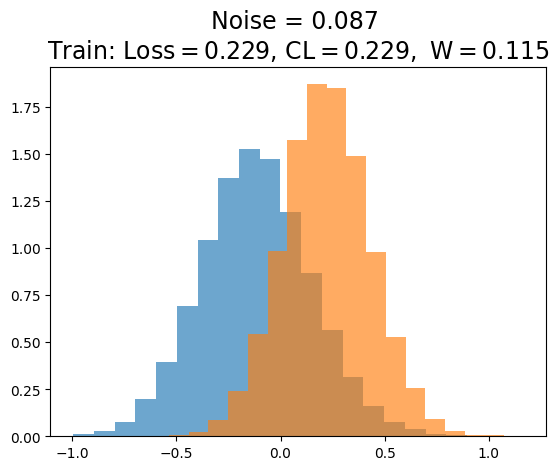

Iteration 100, Loss: 0.0828,  Regr. Loss: 0.0828, Sliced Loss: 0.0378 \ n
 Epsilon= 0.288 
 


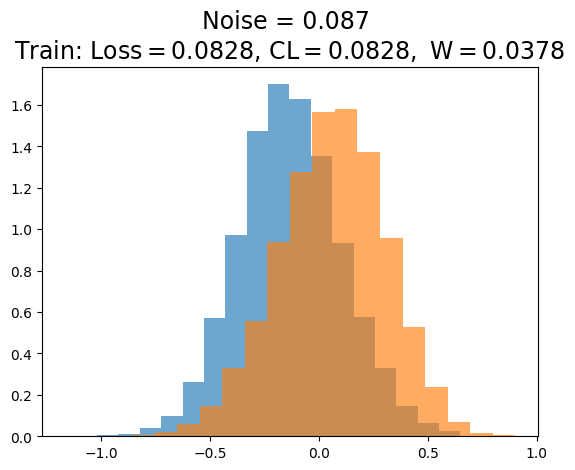

Iteration 200, Loss: 0.0722,  Regr. Loss: 0.0722, Sliced Loss: 0.0515 \ n
 Epsilon= 0.419 
 


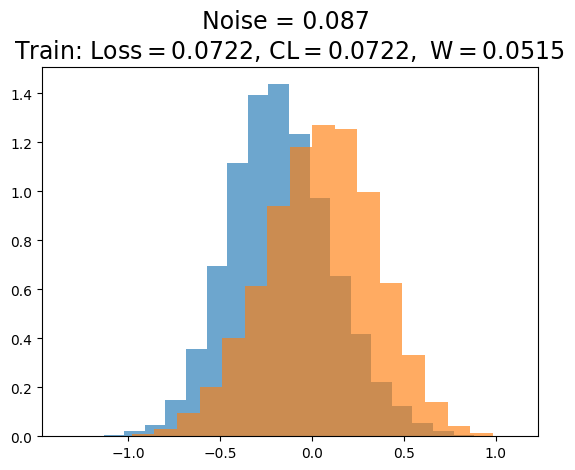

Iteration 300, Loss: 0.0689,  Regr. Loss: 0.0689, Sliced Loss: 0.0693 \ n
 Epsilon= 0.521 
 


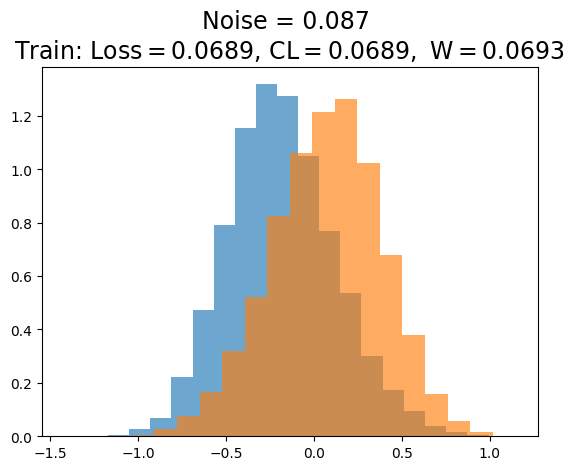

Iteration 400, Loss: 0.0674,  Regr. Loss: 0.0674, Sliced Loss: 0.0628 \ n
 Epsilon= 0.609 
 


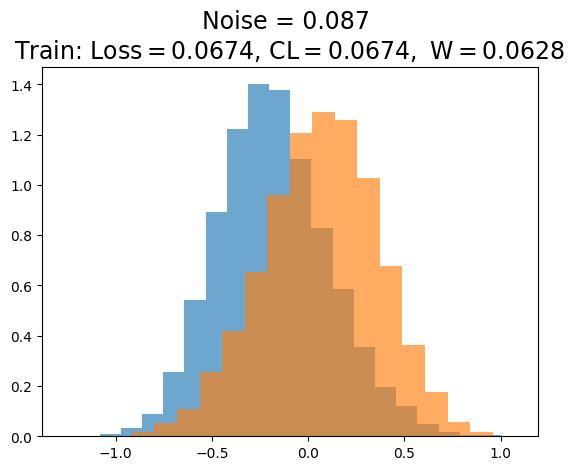

Iteration 500, Loss: 0.0665,  Regr. Loss: 0.0665, Sliced Loss: 0.0704 \ n
 Epsilon= 0.687 
 


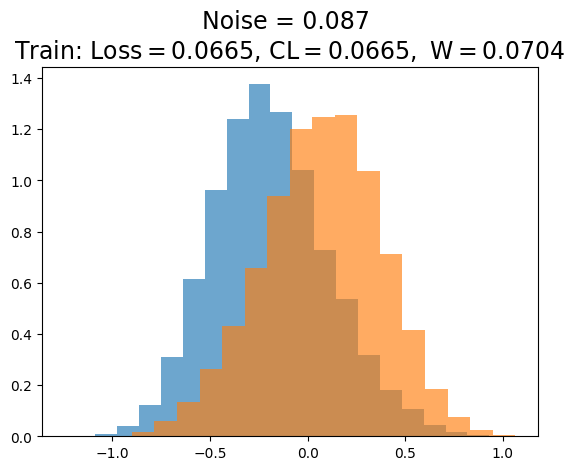

Iteration 600, Loss: 0.0654,  Regr. Loss: 0.0654, Sliced Loss: 0.0677 \ n
 Epsilon= 0.758 
 


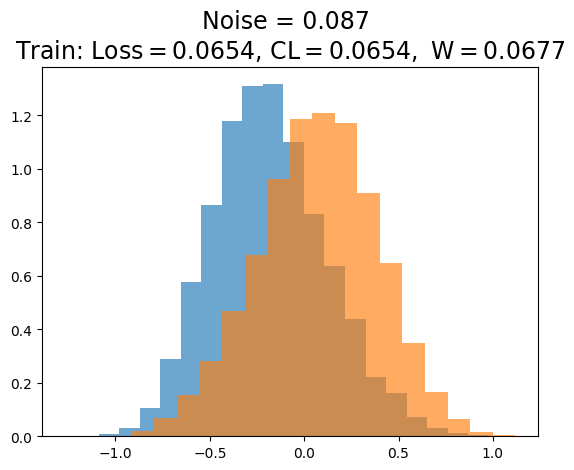

Iteration 700, Loss: 0.0658,  Regr. Loss: 0.0658, Sliced Loss: 0.0648 \ n
 Epsilon= 0.824 
 


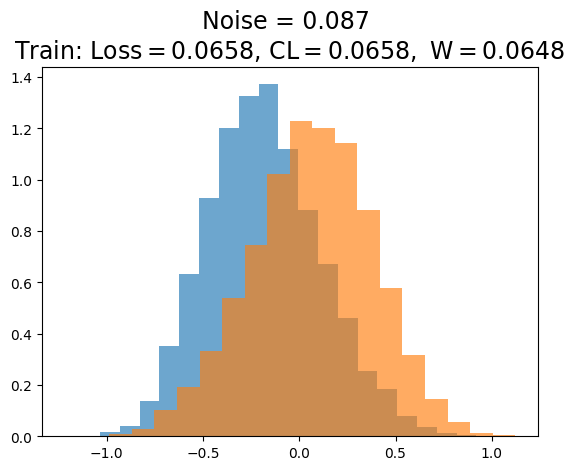

Iteration 800, Loss: 0.0659,  Regr. Loss: 0.0659, Sliced Loss: 0.0615 \ n
 Epsilon= 0.886 
 


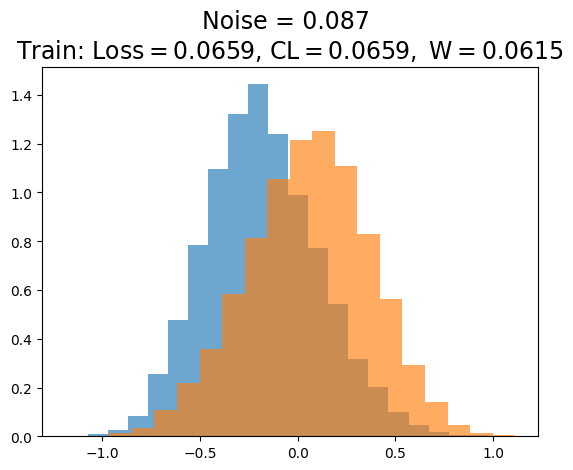

Iteration 900, Loss: 0.0658,  Regr. Loss: 0.0658, Sliced Loss: 0.0664 \ n
 Epsilon= 0.944 
 


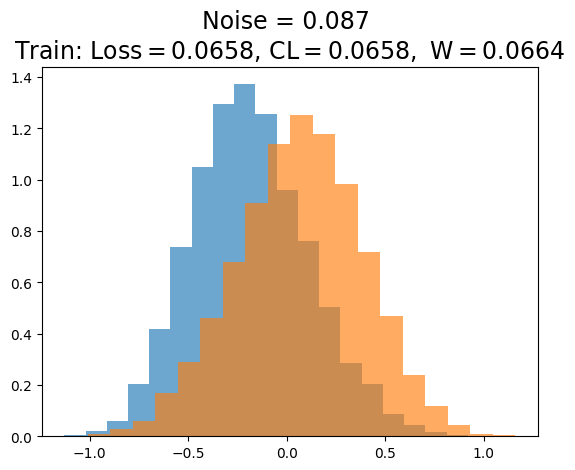

Iteration 1000, Loss: 0.0658,  Regr. Loss: 0.0658, Sliced Loss: 0.0577 \ n
 Epsilon= 1.000 
 


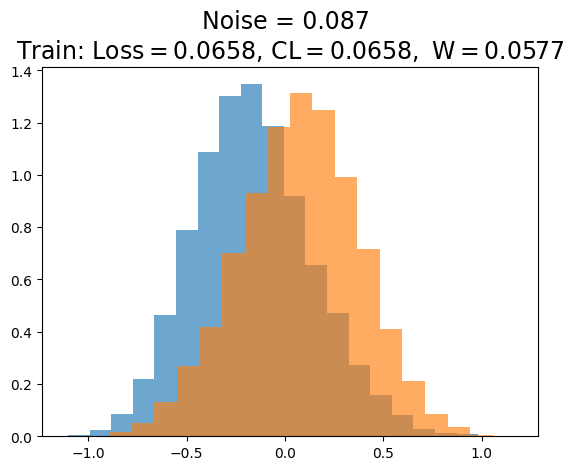

entered !


/home/david/.local/lib/python3.10/site-packages/scs/__init__.py:83: UserWarning: Converting A to a CSC (compressed sparse column) matrix; may take a while.
  warn(


[Postproc α=0] alpha=0.01, ε_post=1.00 → SW²=0.0013, KS=0.0172,  MSE=0.0838
[Postproc α=0] alpha=0.02, ε_post=1.00 → SW²=0.0025, KS=0.0265,  MSE=0.0826
[Postproc α=0] alpha=0.05, ε_post=1.00 → SW²=0.0067, KS=0.0588,  MSE=0.0792
[Postproc α=0] alpha=0.1, ε_post=1.00 → SW²=0.0160, KS=0.1067,  MSE=0.0748
[Postproc α=0] alpha=0.15, ε_post=1.00 → SW²=0.0264, KS=0.1559,  MSE=0.0719
[Postproc α=0] alpha=0.2, ε_post=1.00 → SW²=0.0376, KS=0.2059,  MSE=0.0697
[Postproc α=0] alpha=0.25, ε_post=1.00 → SW²=0.0477, KS=0.2537,  MSE=0.0683
[Postproc α=0] alpha=0.3, ε_post=1.00 → SW²=0.0560, KS=0.3053,  MSE=0.0669
[Postproc α=0] alpha=0.4, ε_post=1.00 → SW²=0.0586, KS=0.3328,  MSE=0.0668


In [152]:
#output_folder = f"images_regression"
#os.makedirs(output_folder, exist_ok=True)  # Crea la carpeta si no existe
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Optimization parameters
num_iterations = 1000
learning_rate = 0.02
d = 1
        
# Clipping values
C0 = 10
M0 = 1/jnp.sqrt(2)
L0 = 1

# batch sizes for each group 
batch_number = 10
minibatch_number = 10
        
m0 = (train_data["n0"]//batch_number) // minibatch_number * minibatch_number
m1 = (train_data["n1"]//batch_number) // minibatch_number * minibatch_number

# Compute R_vector and indexes in the batch
R_vector_batch, indexes_batch = R_and_indexes(m0,m1)

# OPTIMIZER  
optimizer = optax.sgd(learning_rate, momentum = 0)
#optimizer = optax.adam(learning_rate=1e-2)

# DP- parameters
delta = 0.1/(train_data["n0"]+train_data["n1"])


alpha_in = [0]
epsilon_values = [1]
losses_array = jnp.zeros((3,num_iterations))



for alpha in alpha_in:
    counter = -1

    for epsilon in epsilon_values: 
        counter = counter +1 
        print(f'alpha={alpha} epsilon ={epsilon}')

        # compute the noise needed for a given epsilon
        if epsilon == '\infty':
            C = 10**7
            M = 10**7
            L = 10**7
            noise = 0
        else: 
            C = C0 
            M = M0
            L = L0
            sensitivity = (1-alpha)*2*C/(m0+m1) + alpha*16*M*L/min(m0,m1)
            sampling_rate = max(m0/train_data["n0"],m1/train_data["n1"])
            actual_noise = find_noise_for_epsilon(num_iterations, delta, sampling_rate, epsilon, tolerance=1e-4)
            noise = actual_noise*sensitivity

                
        # Initialize model
        key = jax.random.PRNGKey(random_seed)  # we also change the random initialization of the model for the average
        model = fully_connected(key, input_dim=train_data["X"].shape[1])
        params0 = model.params
        flat_params, unflatten_params = ravel_pytree(params0)
        
        # init optimizer state
        opt_state = optimizer.init(flat_params)
            
        # Training loop
        accountant = create_accountant("gdp")
        losses = []
        flat_params, unflatten_params = ravel_pytree(params0)
        key = jax.random.PRNGKey(0)
                      
        # Start the loop
        for iteration in range(num_iterations):
            
            # select randomly a batch, distinguishing between data with A=0 (X) and A=1 (Z)
            key, key1, key2 = split(key,3)
            X0_batch, Y0_batch   = random_batch_X_Y(key1, train_data["X0"], train_data["Y0"], m0)
            X1_batch, Y1_batch   = random_batch_X_Y(key2, train_data["X1"], train_data["Y1"], m1)
                
            # Group the data for the classification loss, where the value of A doesn't play any role
            X_batch = jnp.vstack([X0_batch,X1_batch])
            Y_batch = jnp.concatenate([Y0_batch,Y1_batch])
    
            # wasserstein distance and gradient w.r.t. the parameters for the batch
            gradient_flat_params_sliced = gradient_sliced_loss(flat_params, unflatten_params, X0_batch , X1_batch, model, 
                                                                               R_vector_batch, indexes_batch, M, L)
            
            # gradient and loss with respect to the classification loss
            gradient_flat_params_regression = gradient_regression_loss(flat_params, unflatten_params, X_batch, Y_batch, model, C)
            
            gradient_flat_params = (1-alpha)*gradient_flat_params_regression + alpha*gradient_flat_params_sliced
                 
            # Noisy gradient w.r.t. the flat parameters
            key, subkey = split(key)
            gradient_flat_params_noisy =  gradient_flat_params+ noise*normal(subkey,gradient_flat_params.shape[0])
                
            
            # Perform the accountant step
            if epsilon != '\infty':
                accountant.step(noise_multiplier=actual_noise, sample_rate=sampling_rate)
            
            # Perform the gradient update         
            updates, opt_state = optimizer.update(gradient_flat_params_noisy, opt_state, flat_params)
            flat_params = optax.apply_updates(flat_params, updates)
            #flat_params  = flat_params - (learning_rate) * gradient_flat_params_noisy
    
            U = model.forward(test_data["X0"], unflatten_params(flat_params))
            V = model.forward(test_data["X1"], unflatten_params(flat_params))
            #swd_dist_total,_,_ = sliced_wasserstein(U, V, R_vector, indexes, random_directions, return_gradient = False)
            swd_dist_total,_ ,_= wasserstein_1d(U, V, R_vector_test, indexes_test, return_gradient = False)
            reg_loss_total = loss_mse(flat_params, unflatten_params, model, test_data["X"], test_data["Y"])
            loss = (1-alpha)*reg_loss_total + alpha*swd_dist_total
                
            # Store the loss
            losses_array = losses_array.at[counter,iteration].set(loss)
            losses.append(loss)
            print(f"Iteration {iteration + 1}, Loss: {loss:.4f},  Regr. Loss: {reg_loss_total:.4f}, Sliced Loss: {swd_dist_total:.4f} \ n", end='\r', flush=True)
            #print(f"Iteration {iteration + 1}, Loss: {loss:.4f}", end='\r', flush=True)
            
            # Visualization every x iterations
            if iteration==0 or (iteration+1) % 100 == 0:
                if epsilon != '\infty':
                    epsilon_now = accountant.get_epsilon(delta=delta, poisson = False)
                    print(f'\n Epsilon= {epsilon_now:.3f} \n ')
                                            
                transparency = 0.65
                plt.hist(U, bins=20, alpha=transparency, label=r'$A=0',  align='left', density = True, color = colors[0])  # Segundo conjunto de datos
                plt.hist(V, bins=20, alpha=transparency, label=r'$A=1',  align='left', density = True, color = colors[1])  # Primer conjunto de datos

                plt.title(f'Noise = {noise:.3f} \nTrain: Loss$ = {{{loss:.3}}}$, CL$ = {{{reg_loss_total:.3}}}, $ W$ = {{{swd_dist_total:.3}}}$',fontsize=17)


                U = model.forward(test_data["X0"], unflatten_params(flat_params))
                V = model.forward(test_data["X1"], unflatten_params(flat_params))
                #swd_dist_total,_,_ = sliced_wasserstein(U, V, R_vector, indexes, random_directions, return_gradient = False)
                swd_dist_total,_ ,_= wasserstein_1d(U, V, R_vector_test, indexes_test, return_gradient = False)
                reg_loss_total = loss_mse(flat_params, unflatten_params, model, test_data["X"], test_data["Y"])
                print(f"Iteration {iteration + 1}, Regr. Test Loss: {reg_loss_total:.4f}, Sliced Test Loss: {swd_dist_total:.4f} \ n", end='\r', flush=True)


                plt.show()


        # === Evaluate post-processing if alpha == 0 and epsilon is bounded ===
        if alpha == 0 and epsilon != '\infty' and iteration+1==num_iterations:
            print("entered !")
            postproc_results = evaluate_postprocessing(
                yhat_test=model.forward(test_data["X"], unflatten_params(flat_params)),
                a_test=test_data["A"],
                yhat_train=model.forward(train_data["X"], unflatten_params(flat_params)),
                a_train=train_data["A"],
                y_true=test_data["Y"],
                groups=np.array([0, 1]),
                eps_post=1,
                k_list=[40],
                interval=(-1, 1)
            )

            for (gamma, eps_post), (w2, ks, mse) in postproc_results.items():
                print(f"[Postproc α=0] alpha={gamma}, ε_post={eps_post:.2f} → SW²={w2:.4f}, KS={ks:.4f},  MSE={mse:.4f}")

        

## 2) Fair an private in-processing using our approach for epsilon = 2

alpha=0 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


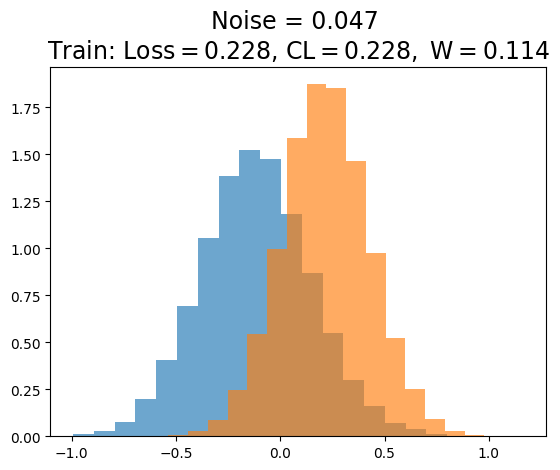

Iteration 100, Loss: 0.0821,  Regr. Loss: 0.0821, Sliced Loss: 0.0413 \ n
 Epsilon= 0.570 
 


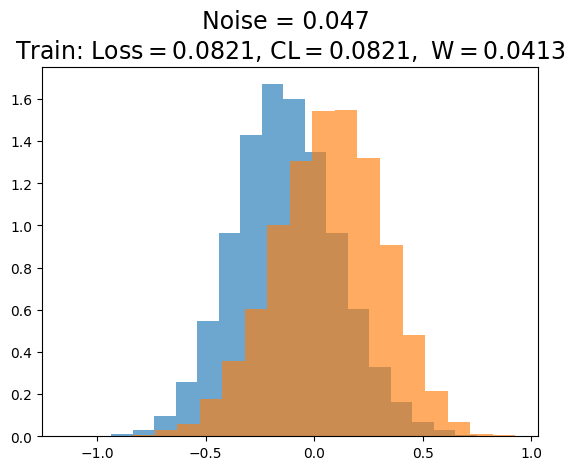

Iteration 200, Loss: 0.0716,  Regr. Loss: 0.0716, Sliced Loss: 0.0543 \ n
 Epsilon= 0.830 
 


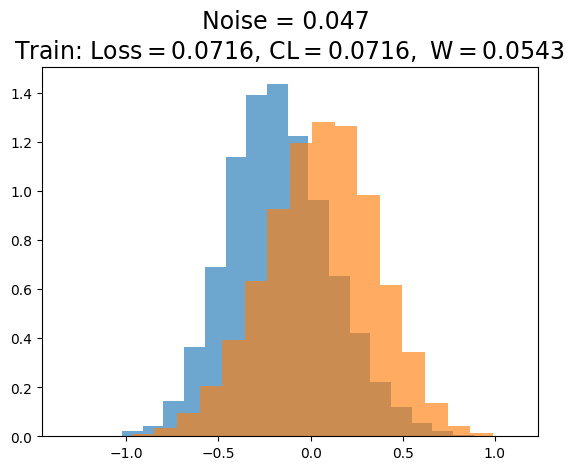

Iteration 300, Loss: 0.0686,  Regr. Loss: 0.0686, Sliced Loss: 0.0650 \ n
 Epsilon= 1.034 
 


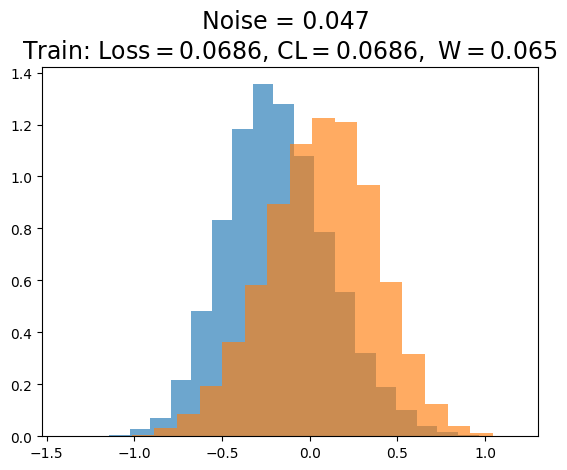

Iteration 400, Loss: 0.0670,  Regr. Loss: 0.0670, Sliced Loss: 0.0629 \ n
 Epsilon= 1.210 
 


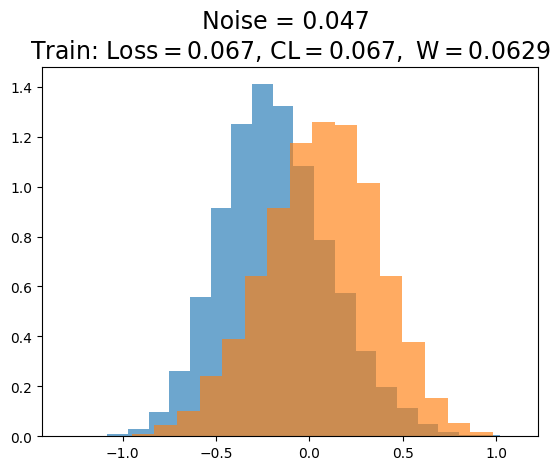

Iteration 500, Loss: 0.0658,  Regr. Loss: 0.0658, Sliced Loss: 0.0673 \ n
 Epsilon= 1.366 
 


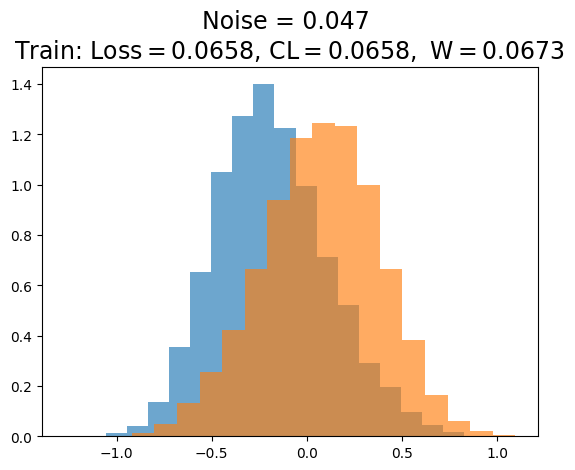

Iteration 600, Loss: 0.0648,  Regr. Loss: 0.0648, Sliced Loss: 0.0657 \ n
 Epsilon= 1.510 
 


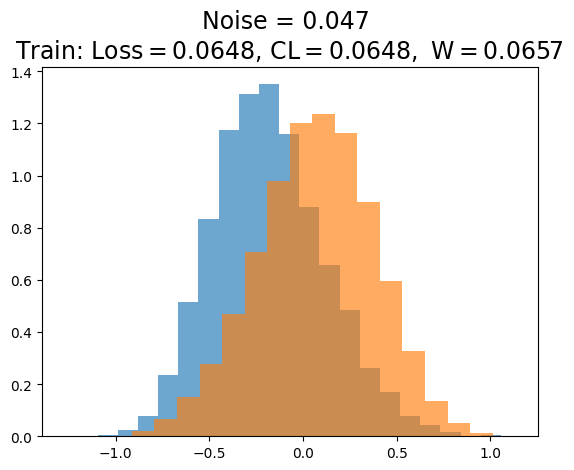

Iteration 700, Loss: 0.0646,  Regr. Loss: 0.0646, Sliced Loss: 0.0635 \ n
 Epsilon= 1.643 
 


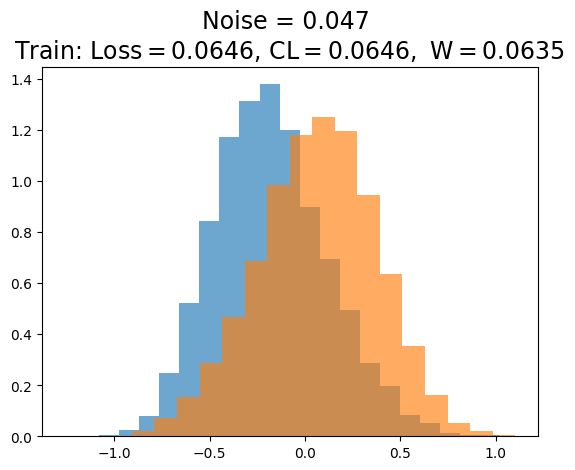

Iteration 800, Loss: 0.0644,  Regr. Loss: 0.0644, Sliced Loss: 0.0632 \ n
 Epsilon= 1.768 
 


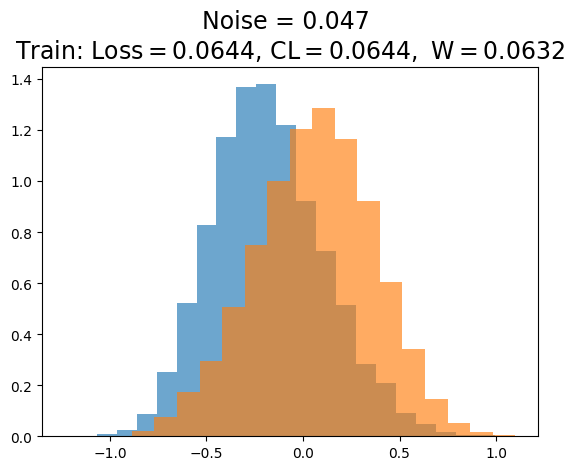

Iteration 900, Loss: 0.0641,  Regr. Loss: 0.0641, Sliced Loss: 0.0659 \ n
 Epsilon= 1.887 
 


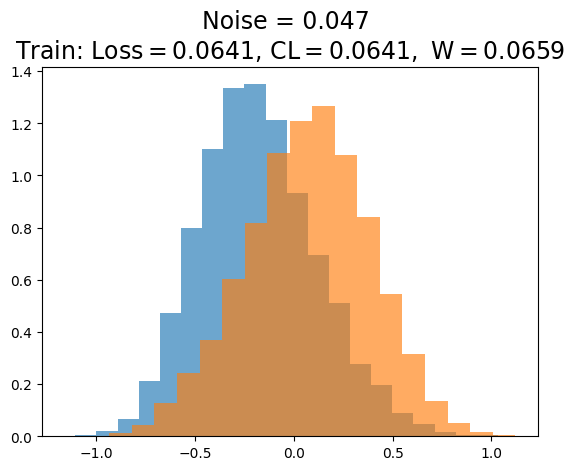

Iteration 1000, Loss: 0.0638,  Regr. Loss: 0.0638, Sliced Loss: 0.0621 \ n
 Epsilon= 2.000 
 


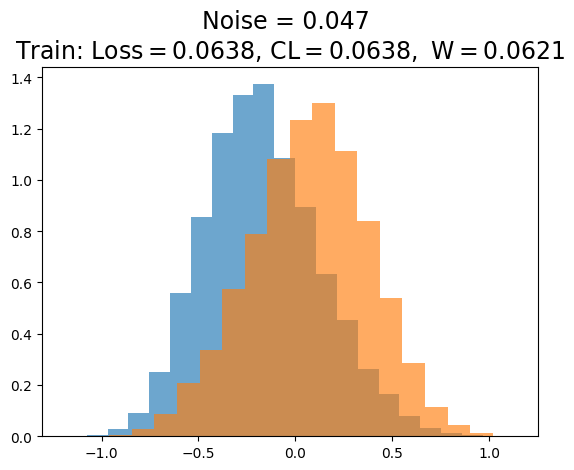

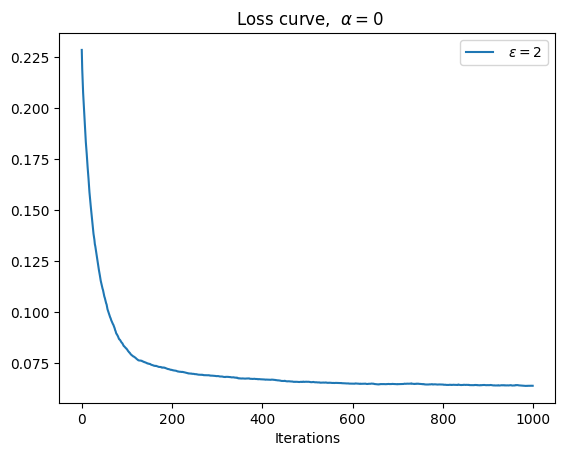

alpha=0.05 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


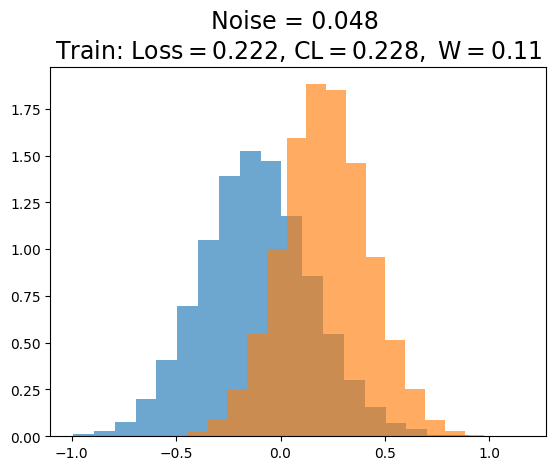

Iteration 100, Loss: 0.0814,  Regr. Loss: 0.0842, Sliced Loss: 0.0295 \ n
 Epsilon= 0.570 
 


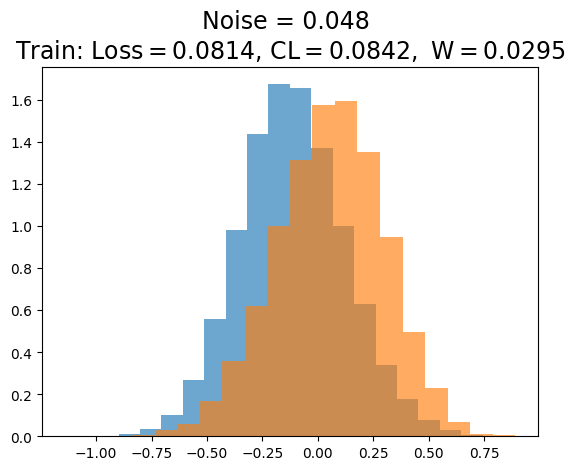

Iteration 200, Loss: 0.0710,  Regr. Loss: 0.0727, Sliced Loss: 0.0388 \ n
 Epsilon= 0.830 
 


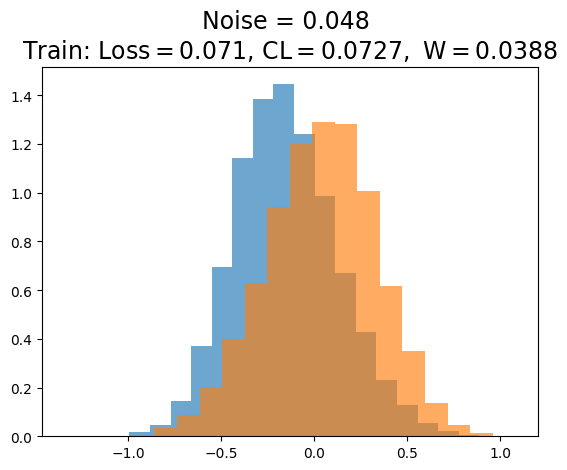

Iteration 300, Loss: 0.0680,  Regr. Loss: 0.0691, Sliced Loss: 0.0475 \ n
 Epsilon= 1.034 
 


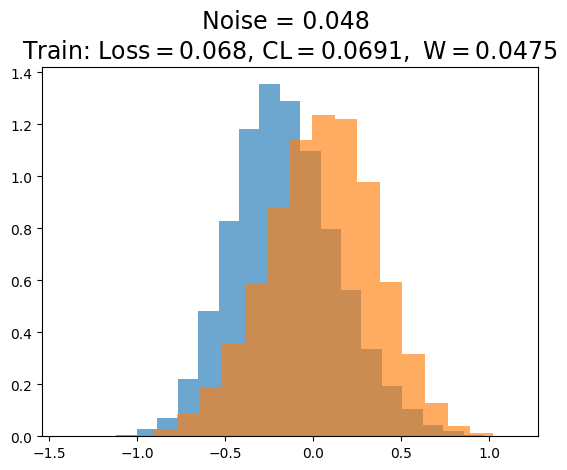

Iteration 400, Loss: 0.0665,  Regr. Loss: 0.0676, Sliced Loss: 0.0454 \ n
 Epsilon= 1.210 
 


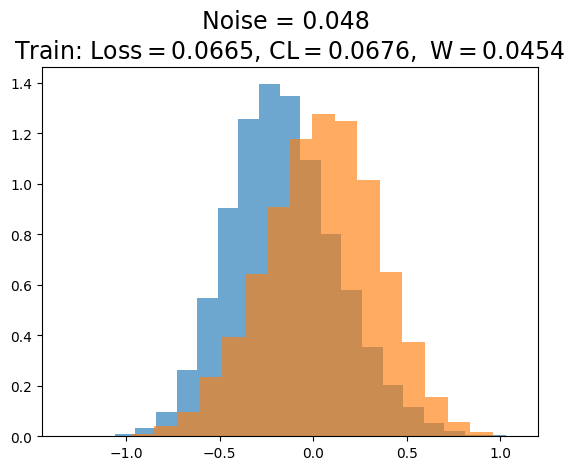

Iteration 500, Loss: 0.0653,  Regr. Loss: 0.0662, Sliced Loss: 0.0494 \ n
 Epsilon= 1.366 
 


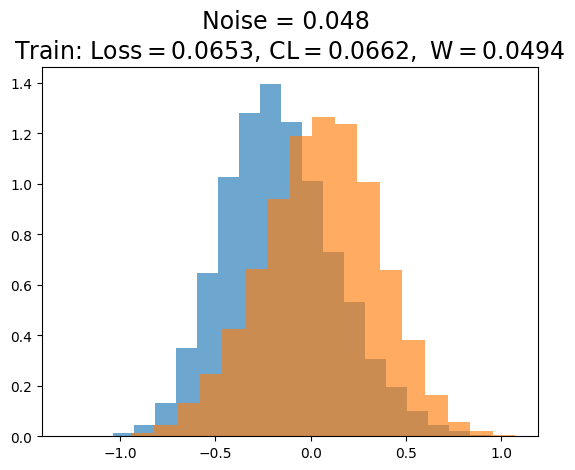

Iteration 600, Loss: 0.0644,  Regr. Loss: 0.0653, Sliced Loss: 0.0477 \ n
 Epsilon= 1.510 
 


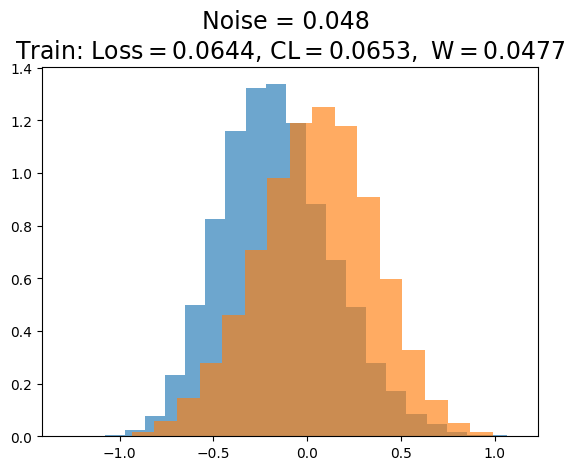

Iteration 700, Loss: 0.0642,  Regr. Loss: 0.0652, Sliced Loss: 0.0459 \ n
 Epsilon= 1.643 
 


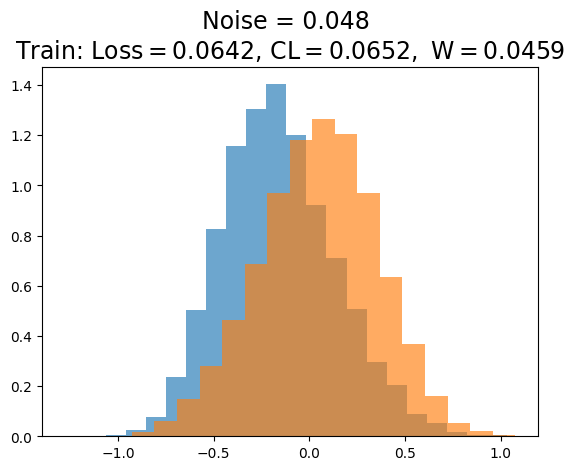

Iteration 800, Loss: 0.0641,  Regr. Loss: 0.0651, Sliced Loss: 0.0456 \ n
 Epsilon= 1.768 
 


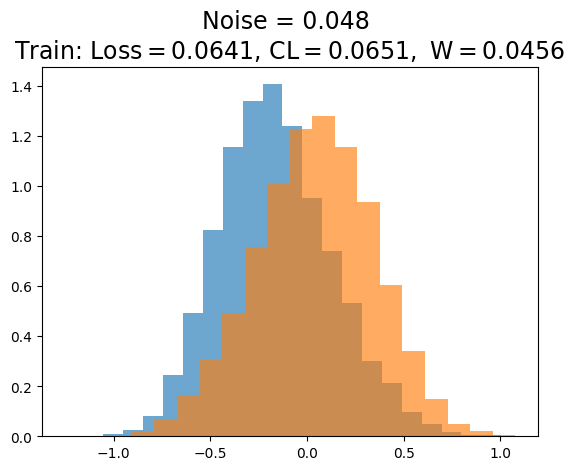

Iteration 900, Loss: 0.0638,  Regr. Loss: 0.0646, Sliced Loss: 0.0476 \ n
 Epsilon= 1.887 
 


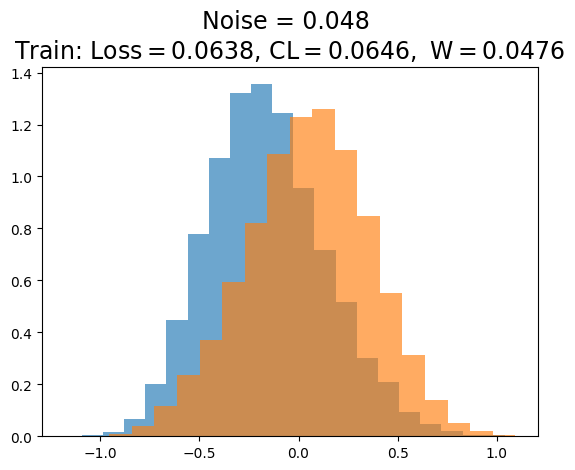

Iteration 1000, Loss: 0.0635,  Regr. Loss: 0.0644, Sliced Loss: 0.0449 \ n
 Epsilon= 2.000 
 


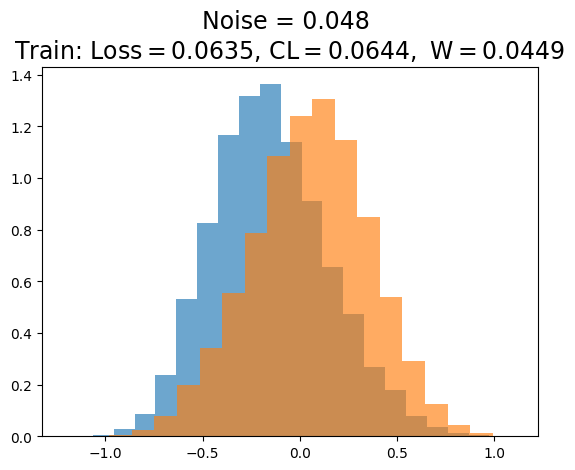

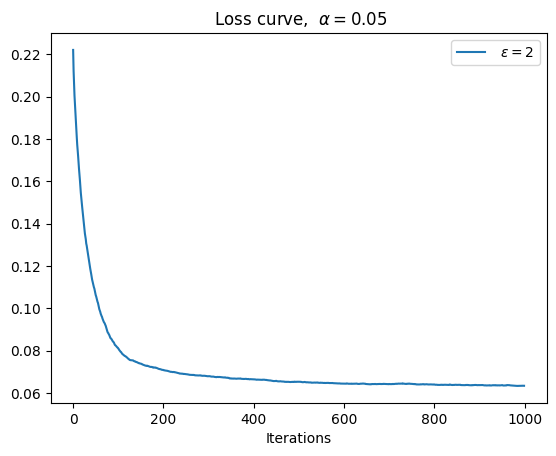

alpha=0.1 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


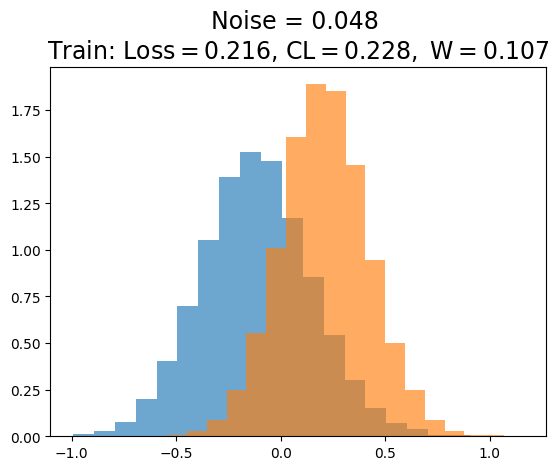

Iteration 100, Loss: 0.0801,  Regr. Loss: 0.0867, Sliced Loss: 0.0213 \ n
 Epsilon= 0.570 
 


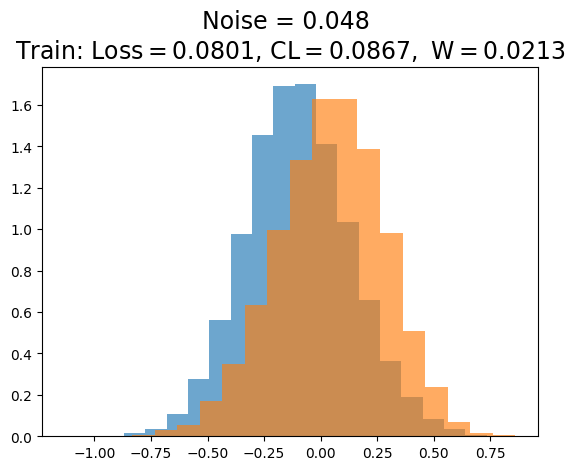

Iteration 200, Loss: 0.0696,  Regr. Loss: 0.0742, Sliced Loss: 0.0282 \ n
 Epsilon= 0.830 
 


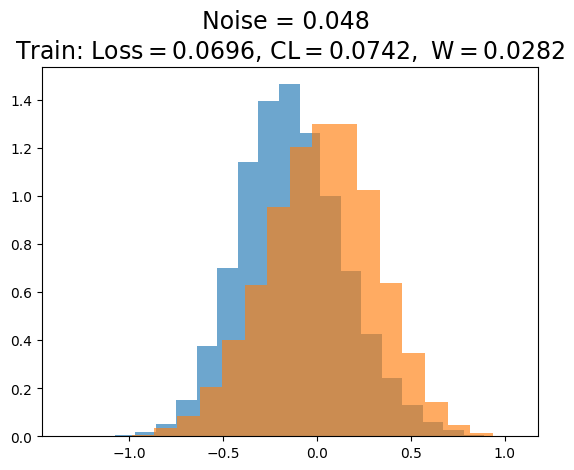

Iteration 300, Loss: 0.0666,  Regr. Loss: 0.0701, Sliced Loss: 0.0353 \ n
 Epsilon= 1.034 
 


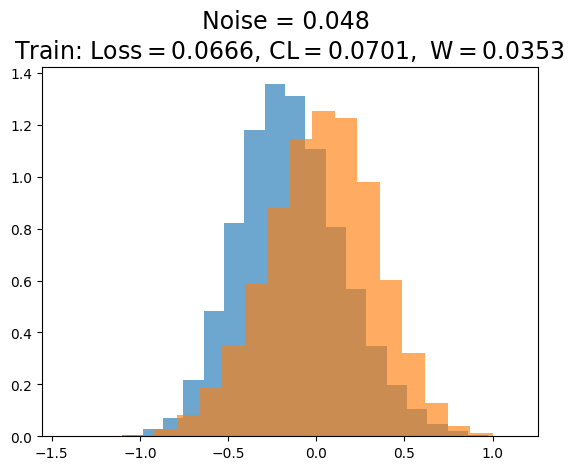

Iteration 400, Loss: 0.0653,  Regr. Loss: 0.0688, Sliced Loss: 0.0334 \ n
 Epsilon= 1.210 
 


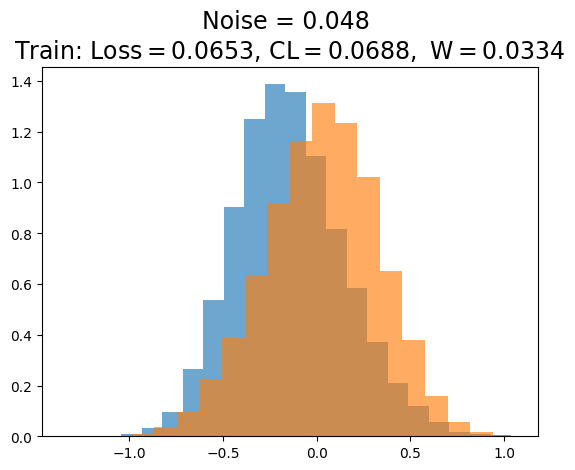

Iteration 500, Loss: 0.0641,  Regr. Loss: 0.0672, Sliced Loss: 0.0368 \ n
 Epsilon= 1.366 
 


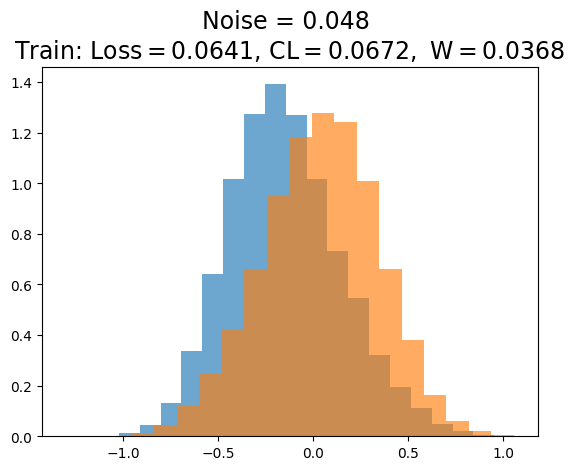

Iteration 600, Loss: 0.0633,  Regr. Loss: 0.0664, Sliced Loss: 0.0352 \ n
 Epsilon= 1.510 
 


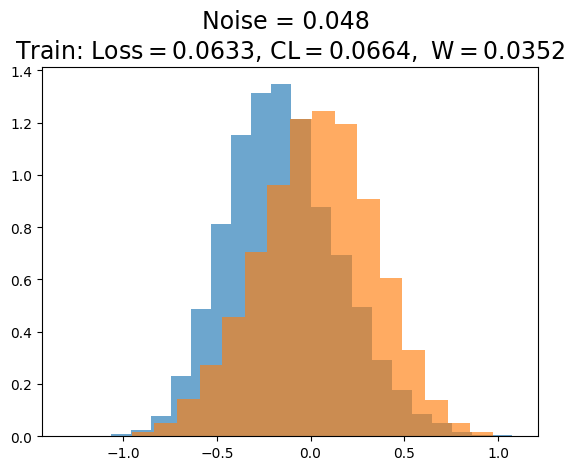

Iteration 700, Loss: 0.0631,  Regr. Loss: 0.0663, Sliced Loss: 0.0338 \ n
 Epsilon= 1.643 
 


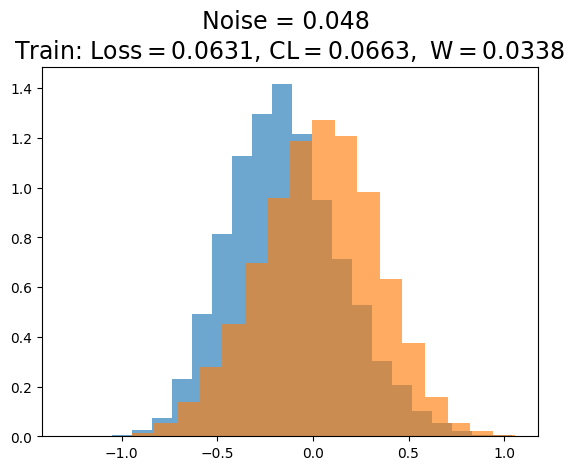

Iteration 800, Loss: 0.0630,  Regr. Loss: 0.0662, Sliced Loss: 0.0335 \ n
 Epsilon= 1.768 
 


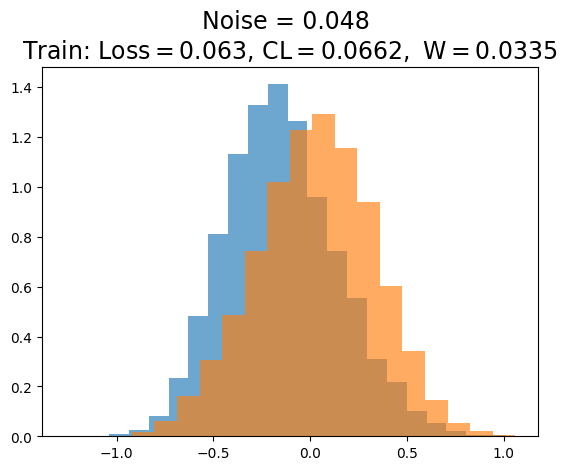

Iteration 900, Loss: 0.0626,  Regr. Loss: 0.0657, Sliced Loss: 0.0349 \ n
 Epsilon= 1.887 
 


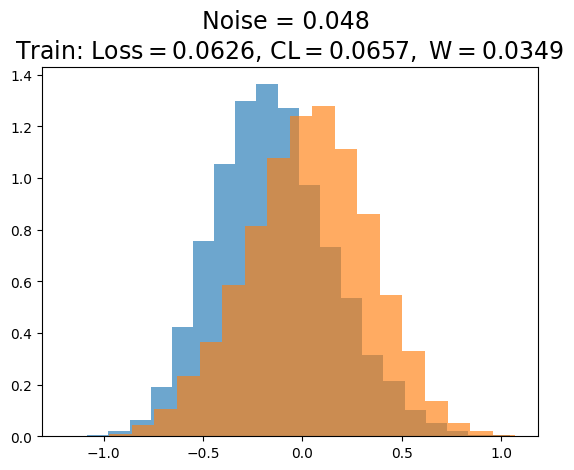

Iteration 1000, Loss: 0.0623,  Regr. Loss: 0.0656, Sliced Loss: 0.0331 \ n
 Epsilon= 2.000 
 


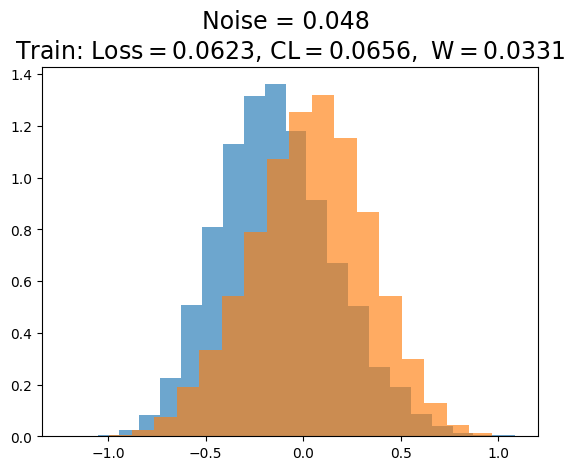

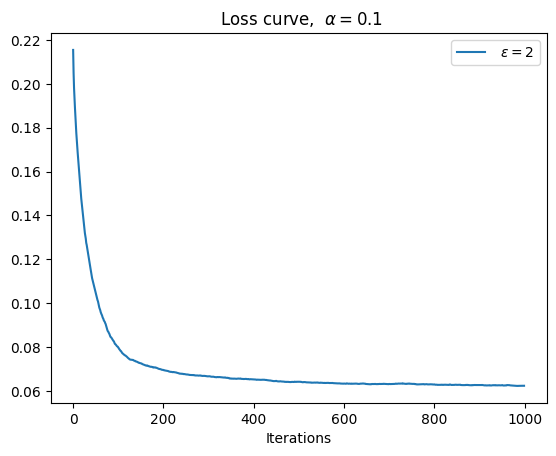

alpha=0.2 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


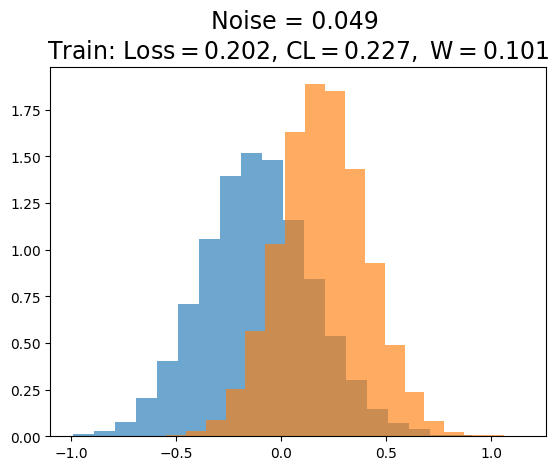

Iteration 100, Loss: 0.0762,  Regr. Loss: 0.0924, Sliced Loss: 0.0114 \ n
 Epsilon= 0.570 
 


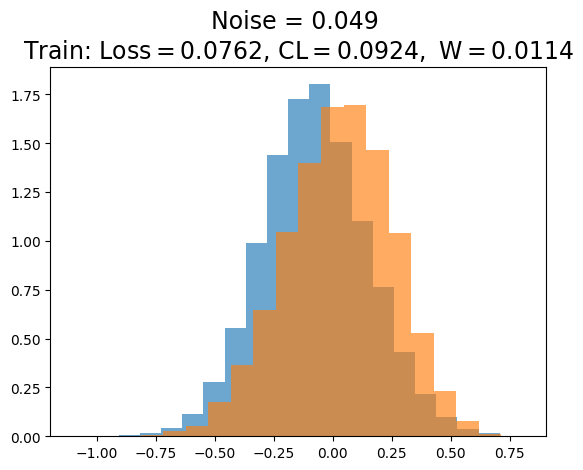

Iteration 200, Loss: 0.0654,  Regr. Loss: 0.0780, Sliced Loss: 0.0152 \ n
 Epsilon= 0.830 
 


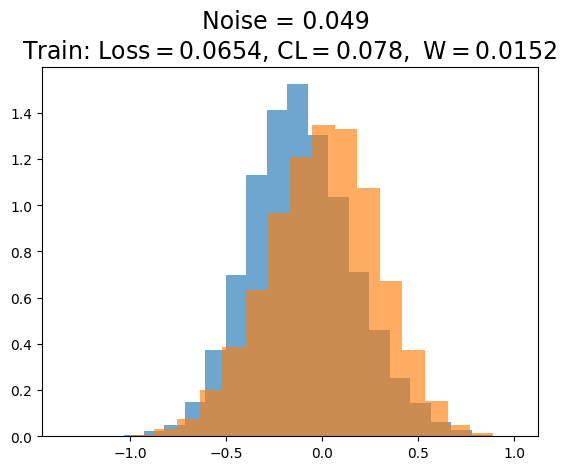

Iteration 300, Loss: 0.0624,  Regr. Loss: 0.0730, Sliced Loss: 0.0201 \ n
 Epsilon= 1.034 
 


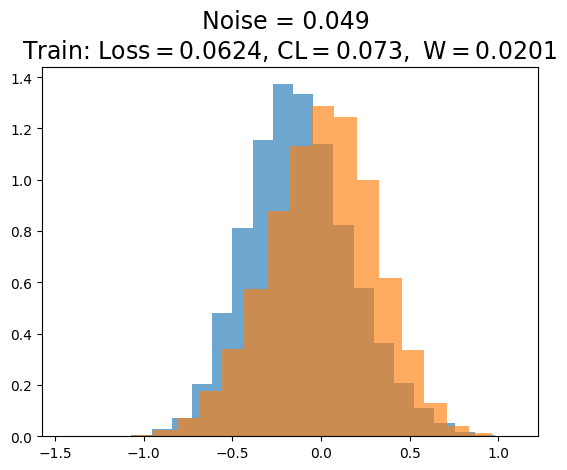

Iteration 400, Loss: 0.0612,  Regr. Loss: 0.0719, Sliced Loss: 0.0186 \ n
 Epsilon= 1.210 
 


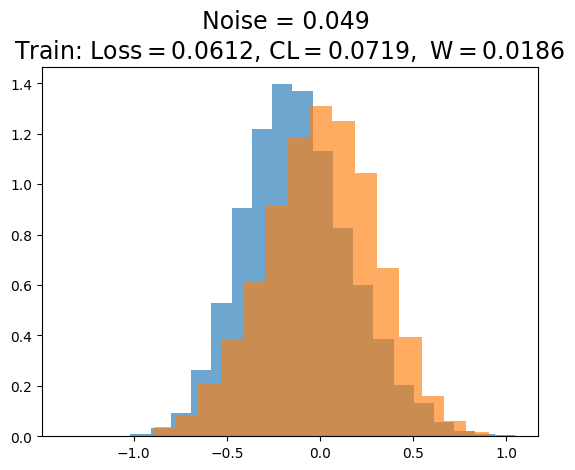

Iteration 500, Loss: 0.0602,  Regr. Loss: 0.0699, Sliced Loss: 0.0213 \ n
 Epsilon= 1.366 
 


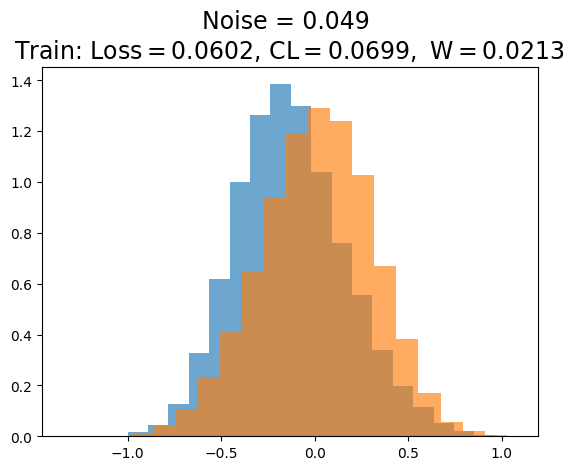

Iteration 600, Loss: 0.0594,  Regr. Loss: 0.0693, Sliced Loss: 0.0198 \ n
 Epsilon= 1.510 
 


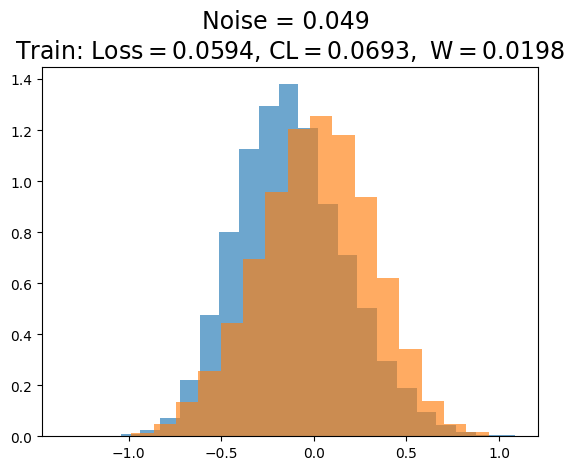

Iteration 700, Loss: 0.0592,  Regr. Loss: 0.0693, Sliced Loss: 0.0189 \ n
 Epsilon= 1.643 
 


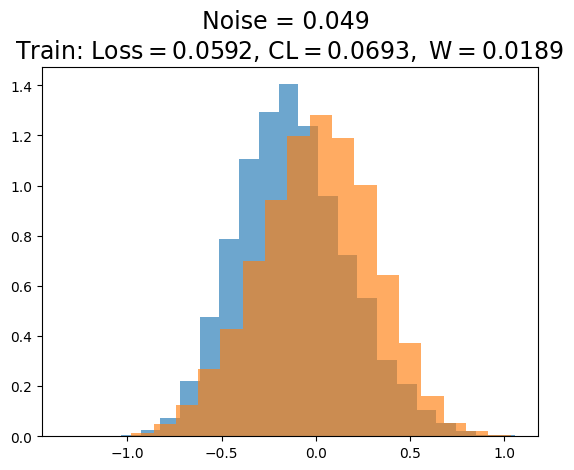

Iteration 800, Loss: 0.0591,  Regr. Loss: 0.0692, Sliced Loss: 0.0187 \ n
 Epsilon= 1.768 
 


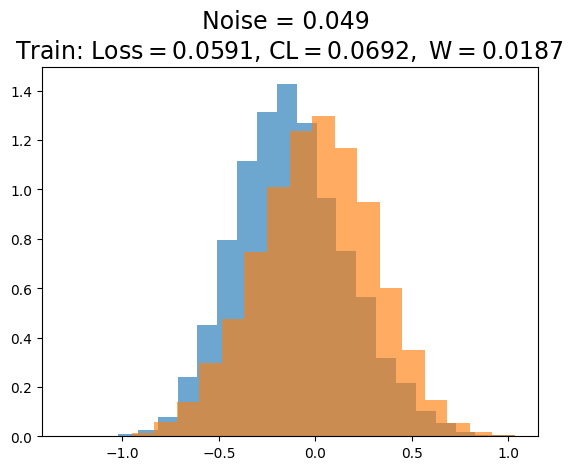

Iteration 900, Loss: 0.0588,  Regr. Loss: 0.0687, Sliced Loss: 0.0195 \ n
 Epsilon= 1.887 
 


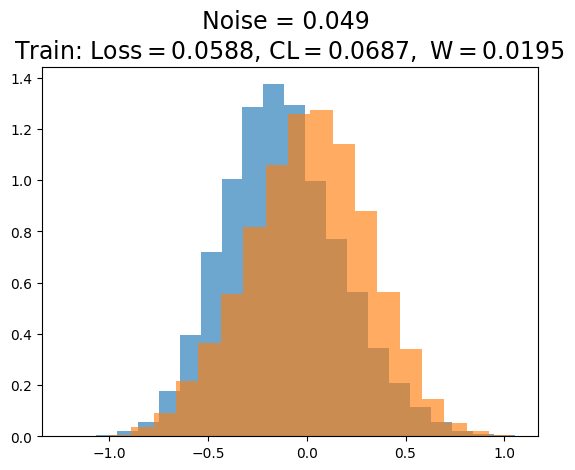

Iteration 1000, Loss: 0.0585,  Regr. Loss: 0.0685, Sliced Loss: 0.0187 \ n
 Epsilon= 2.000 
 


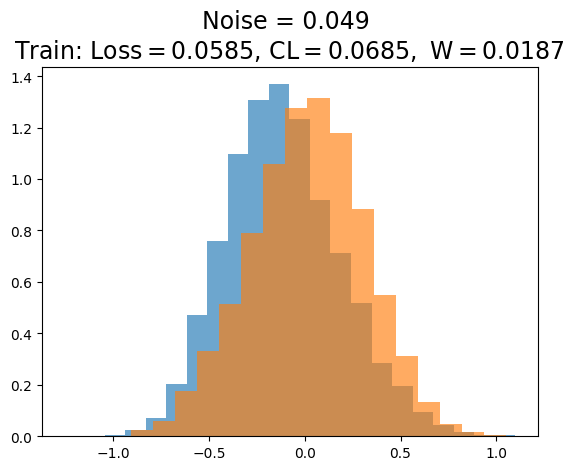

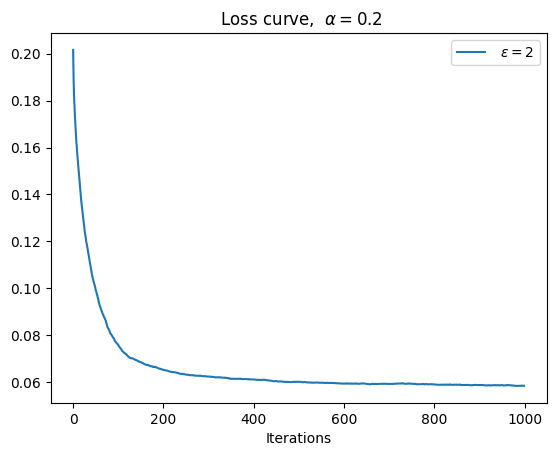

alpha=0.4 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


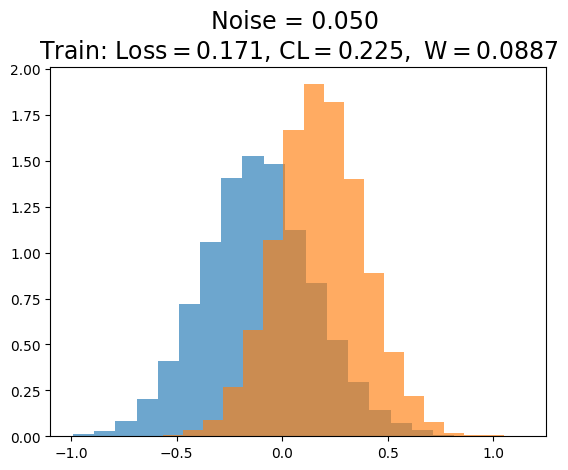

Iteration 100, Loss: 0.0653,  Regr. Loss: 0.1066, Sliced Loss: 0.0034 \ n
 Epsilon= 0.570 
 


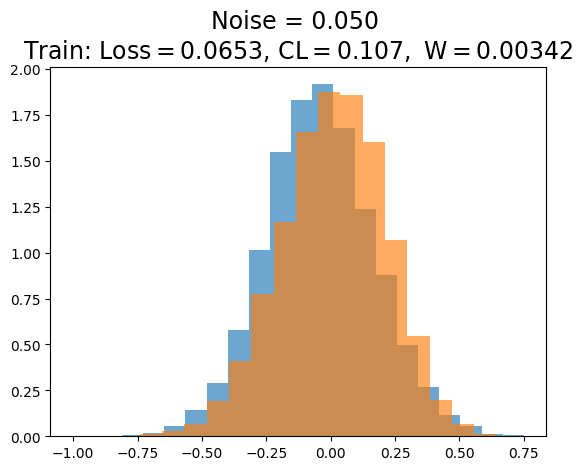

Iteration 200, Loss: 0.0539,  Regr. Loss: 0.0868, Sliced Loss: 0.0045 \ n
 Epsilon= 0.830 
 


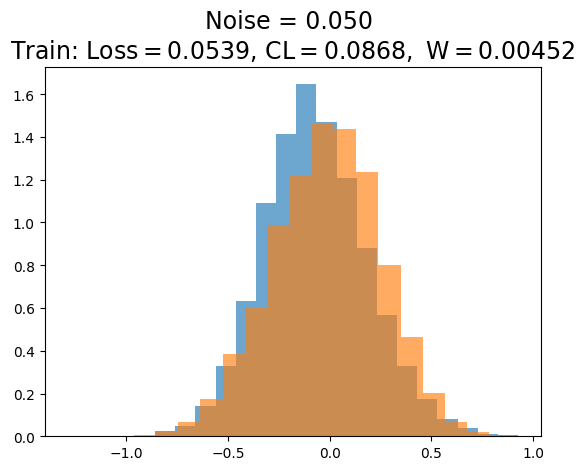

Iteration 300, Loss: 0.0505,  Regr. Loss: 0.0796, Sliced Loss: 0.0070 \ n
 Epsilon= 1.034 
 


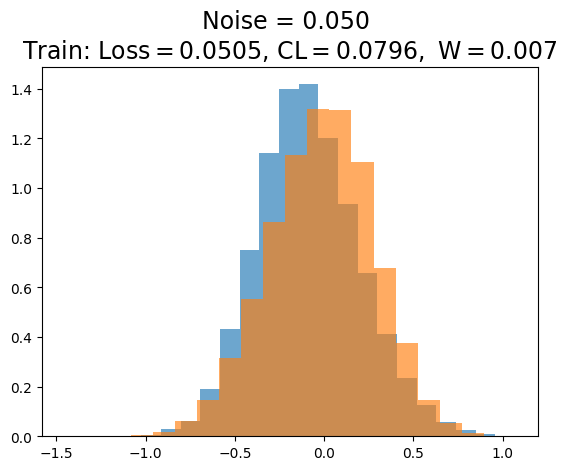

Iteration 400, Loss: 0.0495,  Regr. Loss: 0.0785, Sliced Loss: 0.0061 \ n
 Epsilon= 1.210 
 


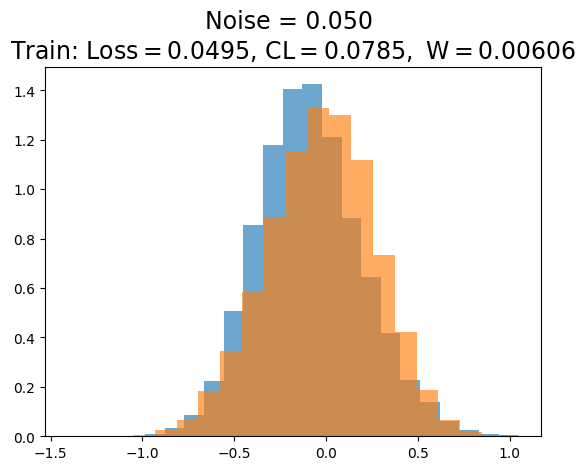

Iteration 500, Loss: 0.0487,  Regr. Loss: 0.0759, Sliced Loss: 0.0078 \ n
 Epsilon= 1.366 
 


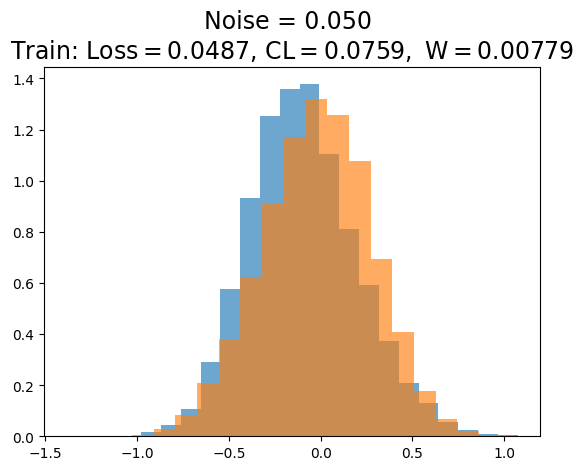

Iteration 600, Loss: 0.0481,  Regr. Loss: 0.0757, Sliced Loss: 0.0067 \ n
 Epsilon= 1.510 
 


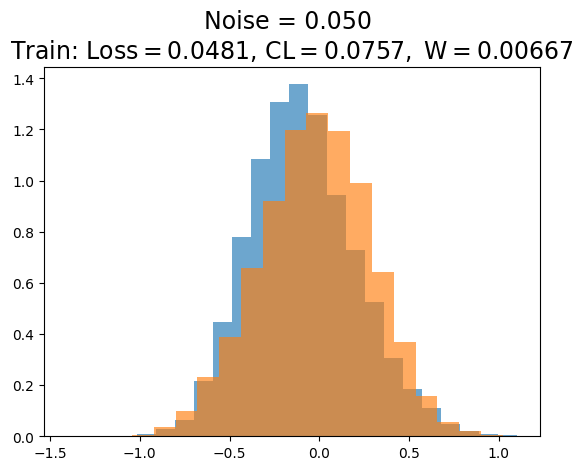

Iteration 700, Loss: 0.0480,  Regr. Loss: 0.0758, Sliced Loss: 0.0063 \ n
 Epsilon= 1.643 
 


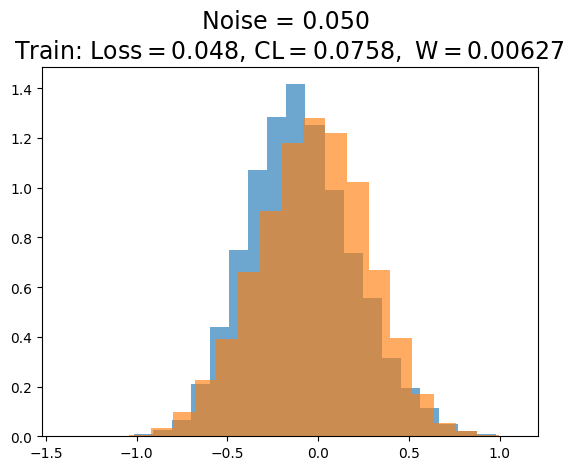

Iteration 800, Loss: 0.0479,  Regr. Loss: 0.0756, Sliced Loss: 0.0062 \ n
 Epsilon= 1.768 
 


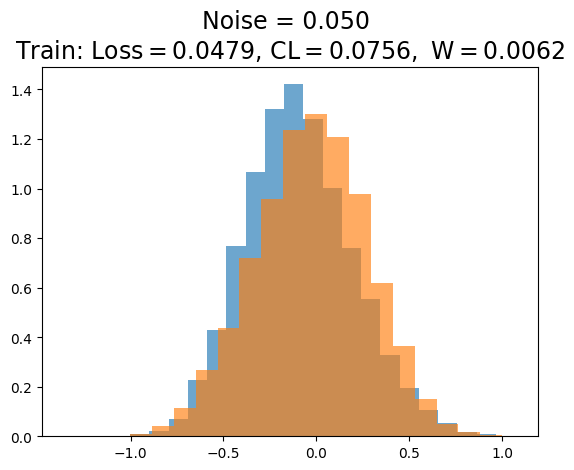

Iteration 900, Loss: 0.0476,  Regr. Loss: 0.0750, Sliced Loss: 0.0064 \ n
 Epsilon= 1.887 
 


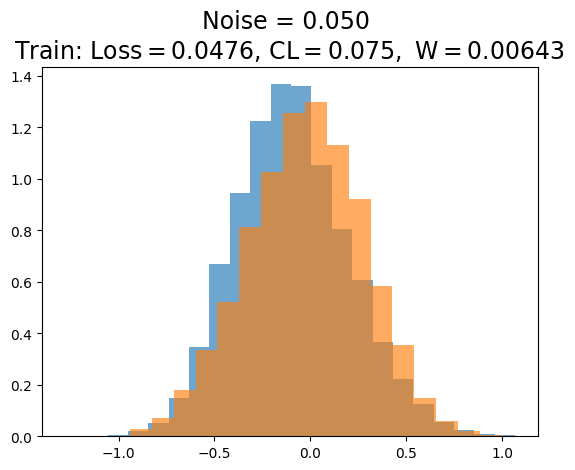

Iteration 1000, Loss: 0.0473,  Regr. Loss: 0.0746, Sliced Loss: 0.0063 \ n
 Epsilon= 2.000 
 


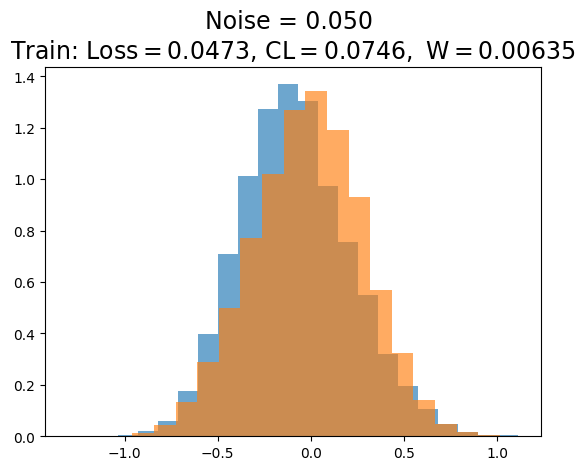

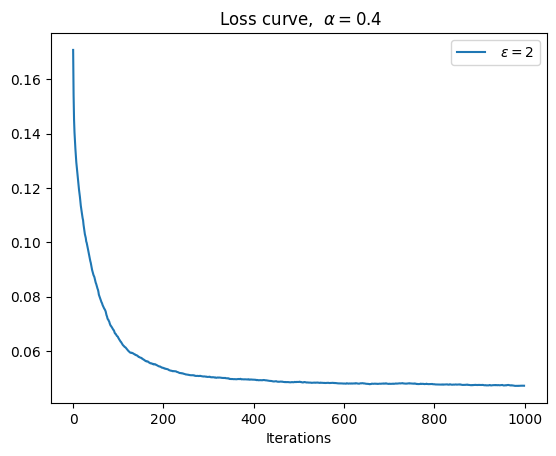

alpha=0.6 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


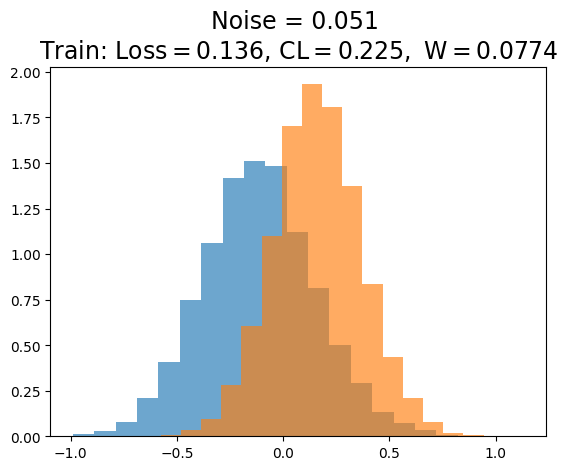

Iteration 100, Loss: 0.0517,  Regr. Loss: 0.1274, Sliced Loss: 0.0012 \ n
 Epsilon= 0.570 
 


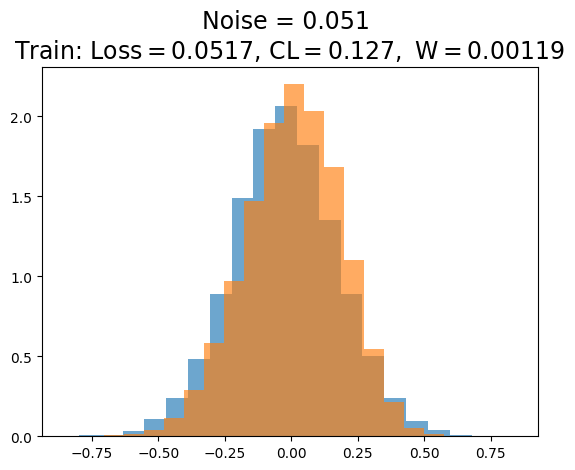

Iteration 200, Loss: 0.0407,  Regr. Loss: 0.1000, Sliced Loss: 0.0012 \ n
 Epsilon= 0.830 
 


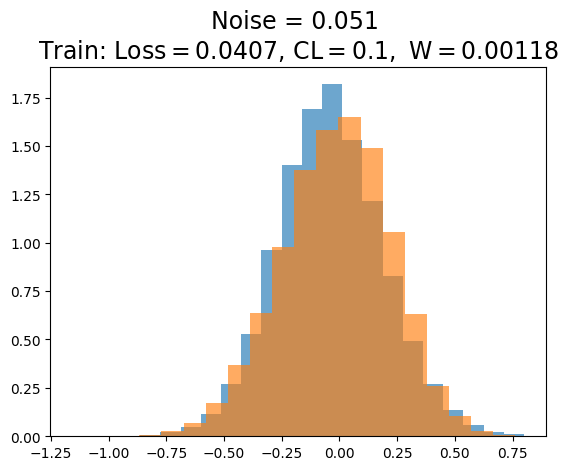

Iteration 300, Loss: 0.0365,  Regr. Loss: 0.0877, Sliced Loss: 0.0024 \ n
 Epsilon= 1.034 
 


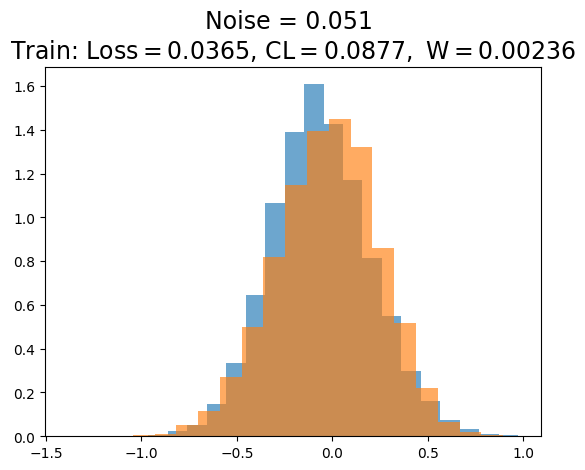

Iteration 400, Loss: 0.0355,  Regr. Loss: 0.0859, Sliced Loss: 0.0019 \ n
 Epsilon= 1.210 
 


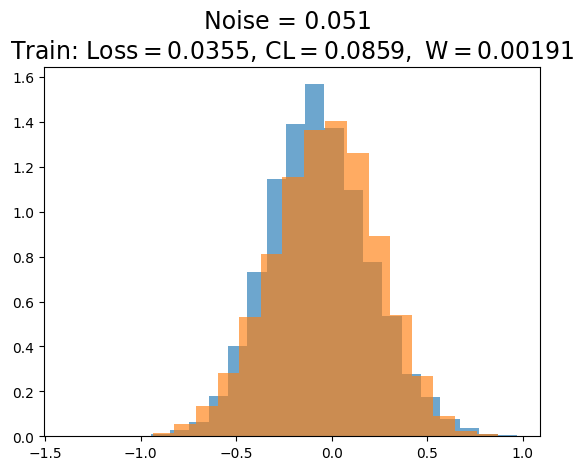

Iteration 500, Loss: 0.0346,  Regr. Loss: 0.0822, Sliced Loss: 0.0029 \ n
 Epsilon= 1.366 
 


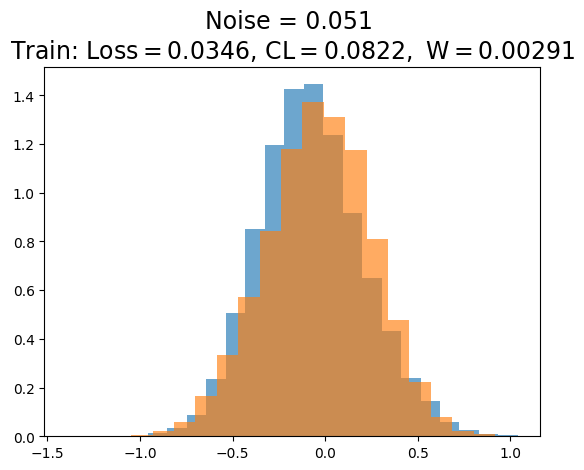

Iteration 600, Loss: 0.0341,  Regr. Loss: 0.0819, Sliced Loss: 0.0022 \ n
 Epsilon= 1.510 
 


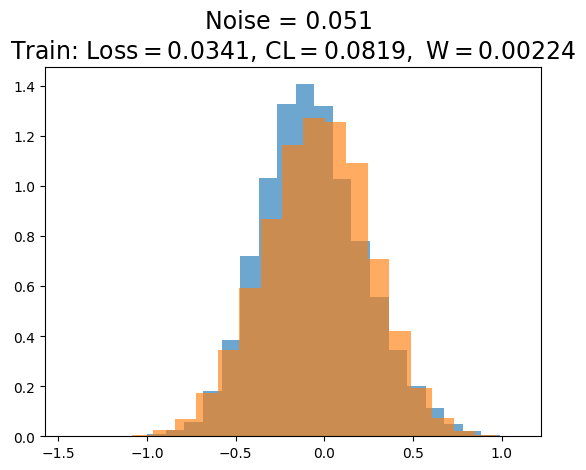

Iteration 700, Loss: 0.0341,  Regr. Loss: 0.0822, Sliced Loss: 0.0020 \ n
 Epsilon= 1.643 
 


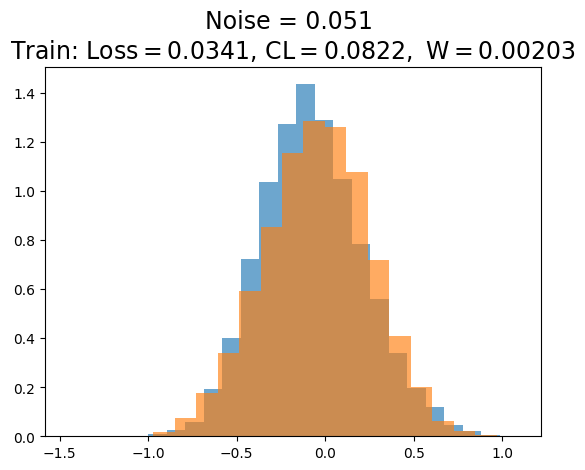

Iteration 800, Loss: 0.0340,  Regr. Loss: 0.0819, Sliced Loss: 0.0020 \ n
 Epsilon= 1.768 
 


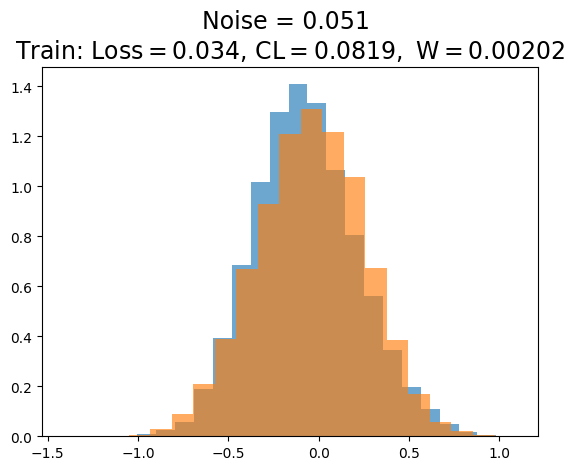

Iteration 900, Loss: 0.0337,  Regr. Loss: 0.0812, Sliced Loss: 0.0021 \ n
 Epsilon= 1.887 
 


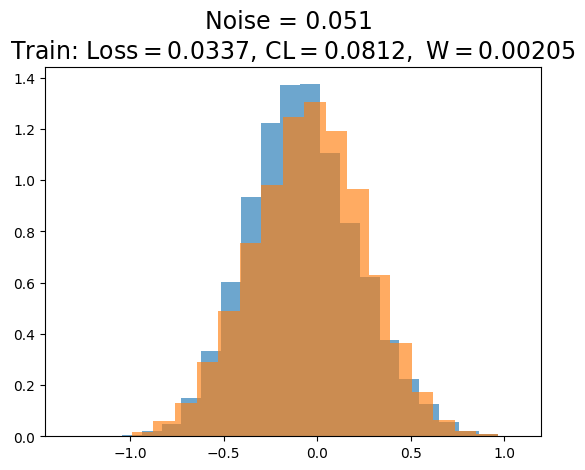

Iteration 1000, Loss: 0.0335,  Regr. Loss: 0.0806, Sliced Loss: 0.0021 \ n
 Epsilon= 2.000 
 


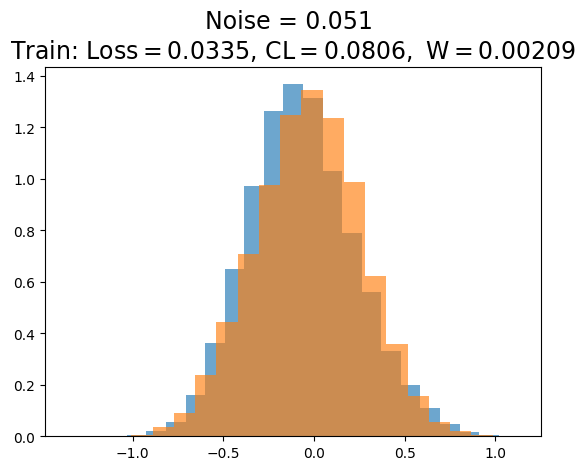

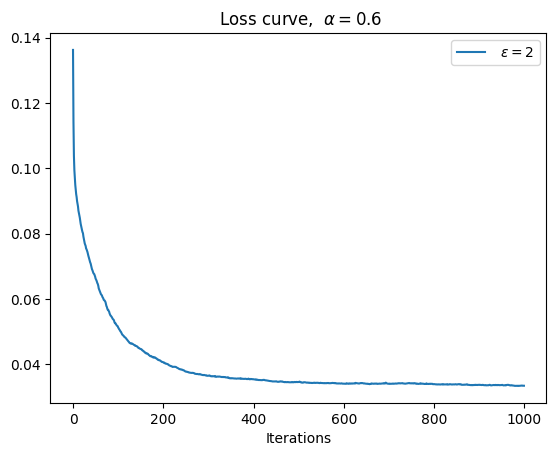

alpha=0.8 epsilon =2


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(



 Epsilon= 0.047 
 


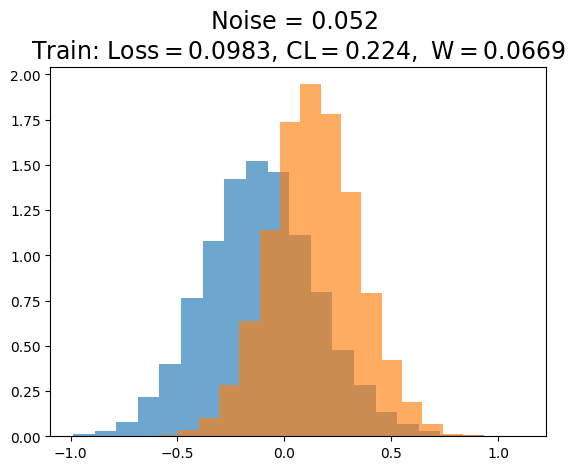

Iteration 100, Loss: 0.0337,  Regr. Loss: 0.1645, Sliced Loss: 0.0010 \ n
 Epsilon= 0.570 
 


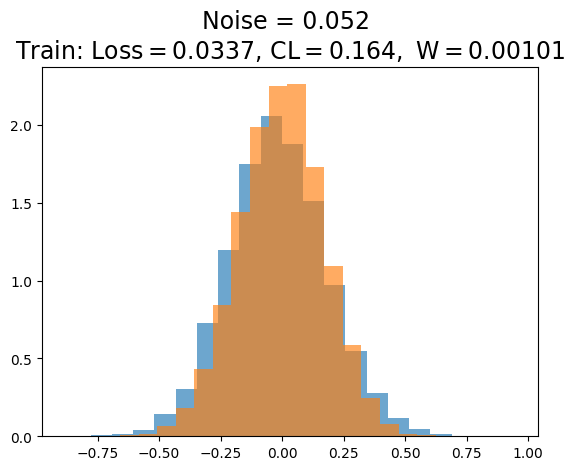

Iteration 200, Loss: 0.0264,  Regr. Loss: 0.1311, Sliced Loss: 0.0002 \ n
 Epsilon= 0.830 
 


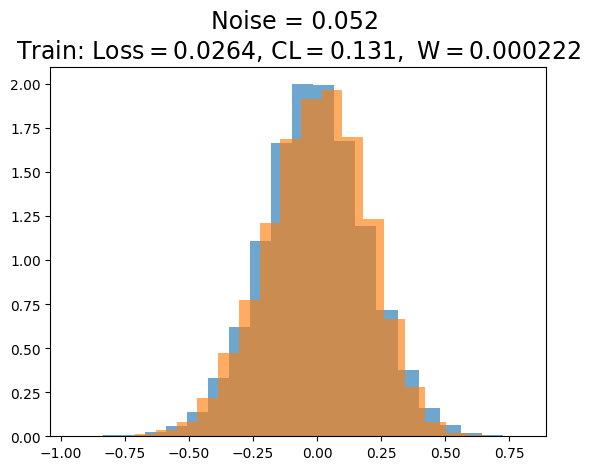

Iteration 300, Loss: 0.0223,  Regr. Loss: 0.1089, Sliced Loss: 0.0006 \ n
 Epsilon= 1.034 
 


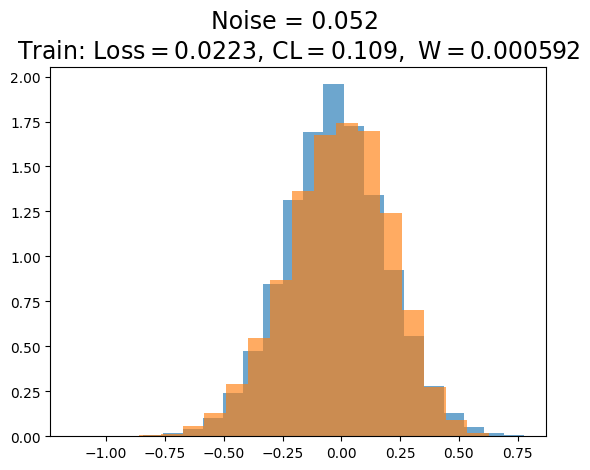

Iteration 400, Loss: 0.0209,  Regr. Loss: 0.1026, Sliced Loss: 0.0005 \ n
 Epsilon= 1.210 
 


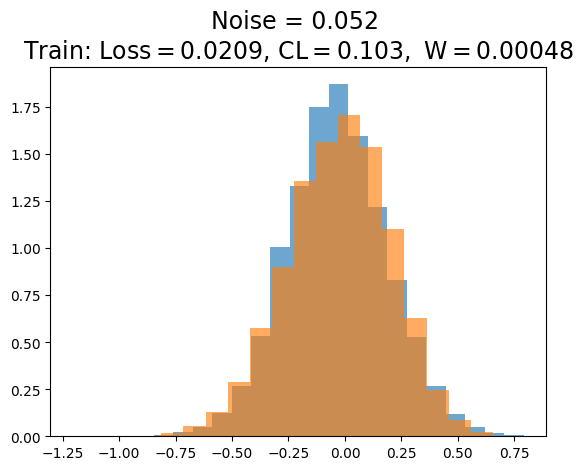

Iteration 500, Loss: 0.0197,  Regr. Loss: 0.0944, Sliced Loss: 0.0010 \ n
 Epsilon= 1.366 
 


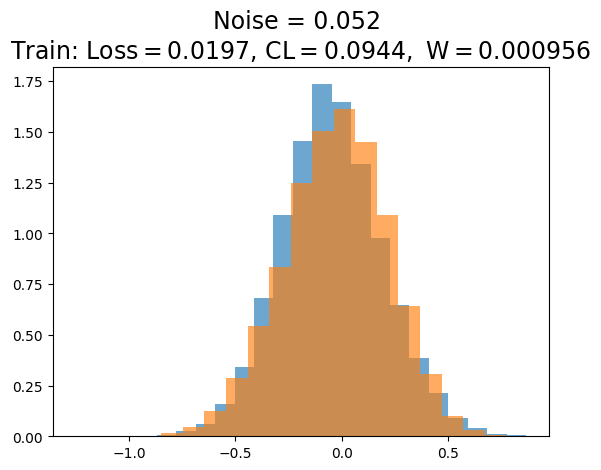

Iteration 600, Loss: 0.0188,  Regr. Loss: 0.0911, Sliced Loss: 0.0007 \ n
 Epsilon= 1.510 
 


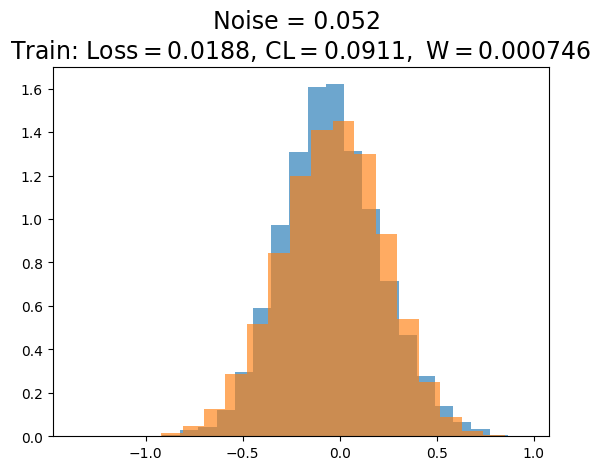

Iteration 700, Loss: 0.0187,  Regr. Loss: 0.0907, Sliced Loss: 0.0007 \ n
 Epsilon= 1.643 
 


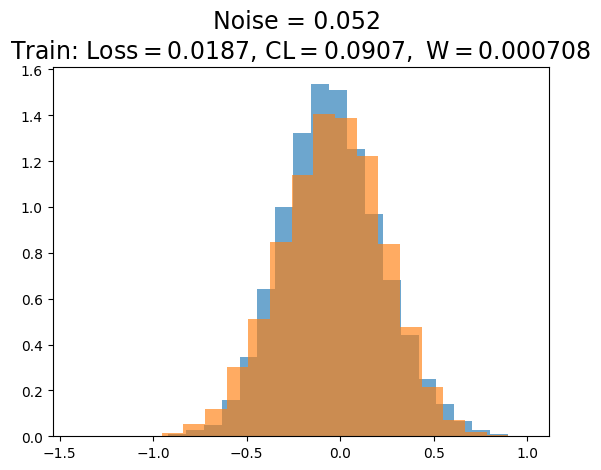

Iteration 800, Loss: 0.0185,  Regr. Loss: 0.0900, Sliced Loss: 0.0006 \ n
 Epsilon= 1.768 
 


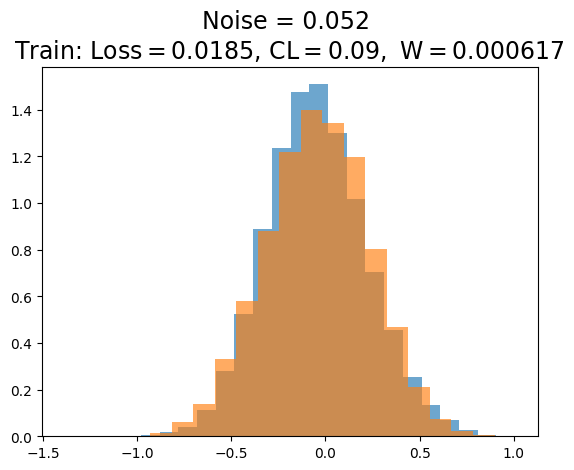

Iteration 900, Loss: 0.0183,  Regr. Loss: 0.0892, Sliced Loss: 0.0006 \ n
 Epsilon= 1.887 
 


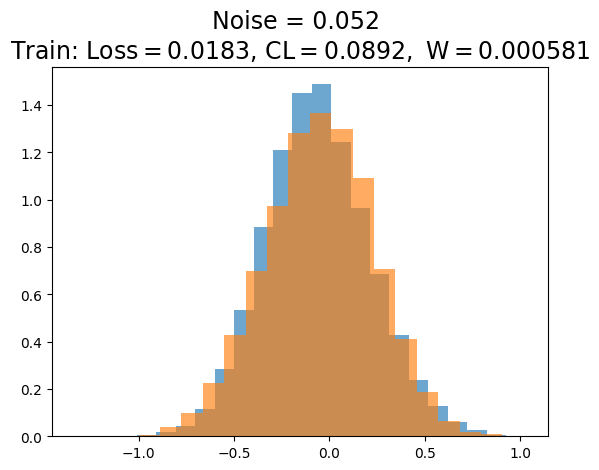

Iteration 1000, Loss: 0.0181,  Regr. Loss: 0.0881, Sliced Loss: 0.0006 \ n
 Epsilon= 2.000 
 


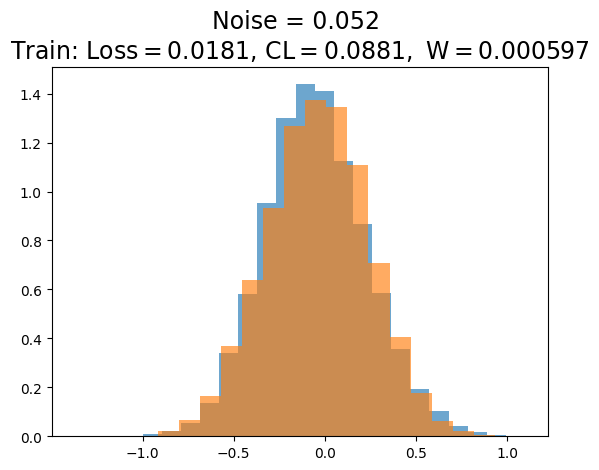

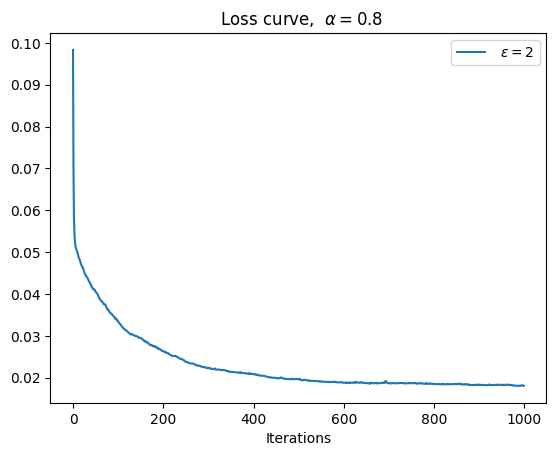

In [153]:
#output_folder = f"images_regression"
#os.makedirs(output_folder, exist_ok=True)  # Crea la carpeta si no existe
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Optimization parameters
num_iterations = 1000
learning_rate = 0.02
d = 1
        
# Clipping values
C0 = 10
M0 = 1/jnp.sqrt(2)
L0 = 1

# batch sizes for each group 
batch_number = 10
minibatch_number = 10
        
m0 = (train_data["n0"]//batch_number) // minibatch_number * minibatch_number
m1 = (train_data["n1"]//batch_number) // minibatch_number * minibatch_number

# Compute R_vector and indexes in the batch
R_vector_batch, indexes_batch = R_and_indexes(m0,m1)

# OPTIMIZER  
optimizer = optax.sgd(learning_rate, momentum = 0)
#optimizer = optax.adam(learning_rate=1e-2)

# DP- parameters
delta = 0.1/(train_data["n0"]+train_data["n1"])


alpha_in = [0,0.05,0.1,0.2,0.4,0.6,0.8]
epsilon_values = [2]
losses_array = jnp.zeros((3,num_iterations))

w2_in = []
ks_in = []
mse_in = []


for alpha in alpha_in:
    counter = -1

    for epsilon in epsilon_values: 
        counter = counter +1 
        print(f'alpha={alpha} epsilon ={epsilon}')

        # compute the noise needed for a given epsilon
        if epsilon == '\infty':
            C = 10**7
            M = 10**7
            L = 10**7
            noise = 0
        else: 
            C = C0 
            M = M0
            L = L0
            sensitivity = (1-alpha)*2*C/(m0+m1) + alpha*16*M*L/min(m0,m1)
            sampling_rate = max(m0/train_data["n0"],m1/train_data["n1"])
            actual_noise = find_noise_for_epsilon(num_iterations, delta, sampling_rate, epsilon, tolerance=1e-4)
            noise = actual_noise*sensitivity

                
        # Initialize model
        key = jax.random.PRNGKey(random_seed) # we also change the random initialization of the model for the average
        model = fully_connected(key, input_dim=train_data["X"].shape[1])
        params0 = model.params
        flat_params, unflatten_params = ravel_pytree(params0)
        
        # init optimizer state
        opt_state = optimizer.init(flat_params)
            
        # Training loop
        accountant = create_accountant("gdp")
        losses = []
        flat_params, unflatten_params = ravel_pytree(params0)
        key = jax.random.PRNGKey(0)
                      
        # Start the loop
        for iteration in range(num_iterations):
            
            # select randomly a batch, distinguishing between data with A=0 (X) and A=1 (Z)
            key, key1, key2 = split(key,3)
            X0_batch, Y0_batch   = random_batch_X_Y(key1, train_data["X0"], train_data["Y0"], m0)
            X1_batch, Y1_batch   = random_batch_X_Y(key2, train_data["X1"], train_data["Y1"], m1)
                
            # Group the data for the classification loss, where the value of A doesn't play any role
            X_batch = jnp.vstack([X0_batch,X1_batch])
            Y_batch = jnp.concatenate([Y0_batch,Y1_batch])
    
            # wasserstein distance and gradient w.r.t. the parameters for the batch
            gradient_flat_params_sliced = gradient_sliced_loss(flat_params, unflatten_params, X0_batch , X1_batch, model, 
                                                                               R_vector_batch, indexes_batch, M, L)
            
            # gradient and loss with respect to the classification loss
            gradient_flat_params_regression = gradient_regression_loss(flat_params, unflatten_params, X_batch, Y_batch, model, C)
            
            gradient_flat_params = (1-alpha)*gradient_flat_params_regression + alpha*gradient_flat_params_sliced
                 
            # Noisy gradient w.r.t. the flat parameters
            key, subkey = split(key)
            gradient_flat_params_noisy =  gradient_flat_params+ noise*normal(subkey,gradient_flat_params.shape[0])
                
            
            # Perform the accountant step
            if epsilon != '\infty':
                accountant.step(noise_multiplier=actual_noise, sample_rate=sampling_rate)
            
            # Perform the gradient update         
            updates, opt_state = optimizer.update(gradient_flat_params_noisy, opt_state, flat_params)
            flat_params = optax.apply_updates(flat_params, updates)
            #flat_params  = flat_params - (learning_rate) * gradient_flat_params_noisy
    
            U = model.forward(test_data["X0"], unflatten_params(flat_params))
            V = model.forward(test_data["X1"], unflatten_params(flat_params))
            #swd_dist_total,_,_ = sliced_wasserstein(U, V, R_vector, indexes, random_directions, return_gradient = False)
            swd_dist_total,_ ,_= wasserstein_1d(U, V, R_vector_test, indexes_test, return_gradient = False)
            reg_loss_total = loss_mse(flat_params, unflatten_params, model, test_data["X"], test_data["Y"])
            loss = (1-alpha)*reg_loss_total + alpha*swd_dist_total
                
            # Store the loss
            losses_array = losses_array.at[counter,iteration].set(loss)
            losses.append(loss)
            print(f"Iteration {iteration + 1}, Loss: {loss:.4f},  Regr. Loss: {reg_loss_total:.4f}, Sliced Loss: {swd_dist_total:.4f} \ n", end='\r', flush=True)
            #print(f"Iteration {iteration + 1}, Loss: {loss:.4f}", end='\r', flush=True)
            
            # Visualization every x iterations
            if iteration==0 or (iteration+1) % 100 == 0:
                if epsilon != '\infty':
                    epsilon_now = accountant.get_epsilon(delta=delta, poisson = False)
                    print(f'\n Epsilon= {epsilon_now:.3f} \n ')
                                            
                transparency = 0.65
                plt.hist(U, bins=20, alpha=transparency, label=r'$A=0',  align='left', density = True, color = colors[0])  
                plt.hist(V, bins=20, alpha=transparency, label=r'$A=1',  align='left', density = True, color = colors[1])  

                plt.title(f'Noise = {noise:.3f} \nTrain: Loss$ = {{{loss:.3}}}$, CL$ = {{{reg_loss_total:.3}}}, $ W$ = {{{swd_dist_total:.3}}}$',fontsize=17)

                U = model.forward(test_data["X0"], unflatten_params(flat_params))
                V = model.forward(test_data["X1"], unflatten_params(flat_params))
                #swd_dist_total,_,_ = sliced_wasserstein(U, V, R_vector, indexes, random_directions, return_gradient = False)
                swd_dist_total,_ ,_= wasserstein_1d(U, V, R_vector_test, indexes_test, return_gradient = False)
                reg_loss_total = loss_mse(flat_params, unflatten_params, model, test_data["X"], test_data["Y"])
                print(f"Iteration {iteration + 1}, Regr. Test Loss: {reg_loss_total:.4f}, Sliced Test Loss: {swd_dist_total:.4f} \ n", end='\r', flush=True)

                plt.show()

        ks_stat, _ = ks_2samp(U, V)

        ks_in.append(ks_stat)
        w2_in.append(swd_dist_total)
        mse_in.append(reg_loss_total)
                                    
        # Plot of the loss curve for different values of epsilon
        for i in range(counter+1):
            plt.plot(losses_array[i,:], label = f' $\\epsilon = {epsilon_values[i]}$')
        plt.legend()
        plt.xlabel("Iterations")
        plt.title(f' Loss curve,  $\\alpha = {alpha}$')
        plt.show()


    


### Plot the Trade-off between fairness and accuracy.

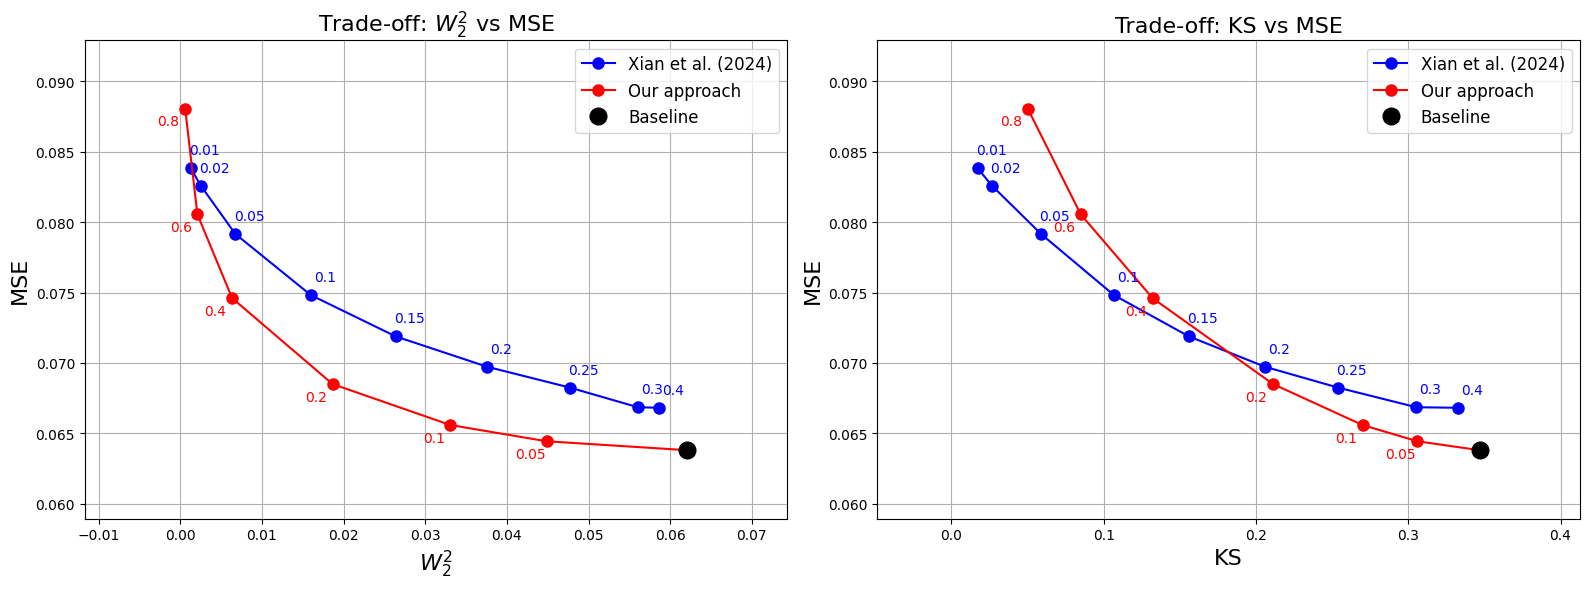

In [154]:
alpha_post = [k[0] for k in postproc_results.keys()] 
w2_post = [float(v[0]) for v in postproc_results.values()]
ks_post = [v[1] for v in postproc_results.values()] 
mse_post = [v[2] for v in postproc_results.values()]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# -------------------------
# Left plot: W2 vs MSE
# -------------------------
ax = axes[0]

# Blue line for postprocessing
ax.plot(w2_post, mse_post, '-o', color='blue', markersize=8, label='Xian et al. (2024)')
# Red line for our approach
ax.plot(w2_in, mse_in, '-o', color='red', markersize=8, label='Our approach')
# Baseline first point
ax.plot(w2_in[0], mse_in[0], 'o', color='black', markersize=12, label='Baseline')

# Annotations
for g, xx, yy in zip(alpha_post, w2_post, mse_post):
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(10,10),
                ha='center', color='blue')
for i, (g, xx, yy) in enumerate(zip(alpha_in, w2_in, mse_in)):
    if i == 0:
        continue
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(-12,-12),
                ha='center', color='red')

ax.set_title(r"Trade-off: $W_2^2$ vs MSE",fontsize=16)
ax.set_xlabel(r"$W_2^2$",fontsize=16)
ax.set_ylabel("MSE",fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)
ax.margins(0.2, 0.2)

# -------------------------
# Right plot: KS vs MSE
# -------------------------
ax = axes[1]

# Blue line for postprocessing
ax.plot(ks_post, mse_post, '-o', color='blue', markersize=8, label='Xian et al. (2024)')
# Red line for our approach
ax.plot(ks_in, mse_in, '-o', color='red', markersize=8, label='Our approach')
# Baseline first point
ax.plot(ks_in[0], mse_in[0], 'o', color='black', markersize=12, label='Baseline')

# Annotations
for g, xx, yy in zip(alpha_post, ks_post, mse_post):
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(10,10),
                ha='center', color='blue')
for i, (g, xx, yy) in enumerate(zip(alpha_in, ks_in, mse_in)):
    if i == 0:
        continue
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(-12,-12),
                ha='center', color='red')

ax.set_title("Trade-off: KS vs MSE",fontsize=16)
ax.set_xlabel("KS",fontsize=16)
ax.set_ylabel("MSE",fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)
ax.margins(0.2, 0.2)

plt.tight_layout()
filename = f"result_seeds/tradeoffs_{random_seed}.pdf"
plt.savefig(filename, dpi=300)

plt.show()


**Save the results (for averaging)**

In [155]:
filename = f"result_seeds/seed_{random_seed}.npz"
np.savez(filename, w2_post=w2_post, ks_post=ks_post, mse_post=mse_post, w2_in = w2_in, ks_in=ks_in, mse_in=mse_in )    

### Average: Run all the previous section for different values of random_seed (in the data generation), and then run this section

In [156]:
# Initialize average arrays
av_w2_post = np.zeros(len(alpha_post))
av_ks_post = np.zeros(len(alpha_post))
av_mse_post = np.zeros(len(alpha_post))
av_w2_in = np.zeros(len(alpha_in))
av_ks_in = np.zeros(len(alpha_in))
av_mse_in = np.zeros(len(alpha_in))

In [157]:
all_seeds = [42,43,44,45,46]
T = len(all_seeds)
for rs in all_seeds:
    filename = f"result_seeds/seed_{rs}.npz"
    data = np.load(filename)
    
    # Accumulate the averages
    av_w2_post += data['w2_post'] / T
    av_ks_post += data['ks_post'] / T
    av_mse_post += data['mse_post'] / T
    av_w2_in += data['w2_in'] / T
    av_ks_in += data['ks_in'] / T
    av_mse_in += data['mse_in'] / T

**Plot the average tradeoff**

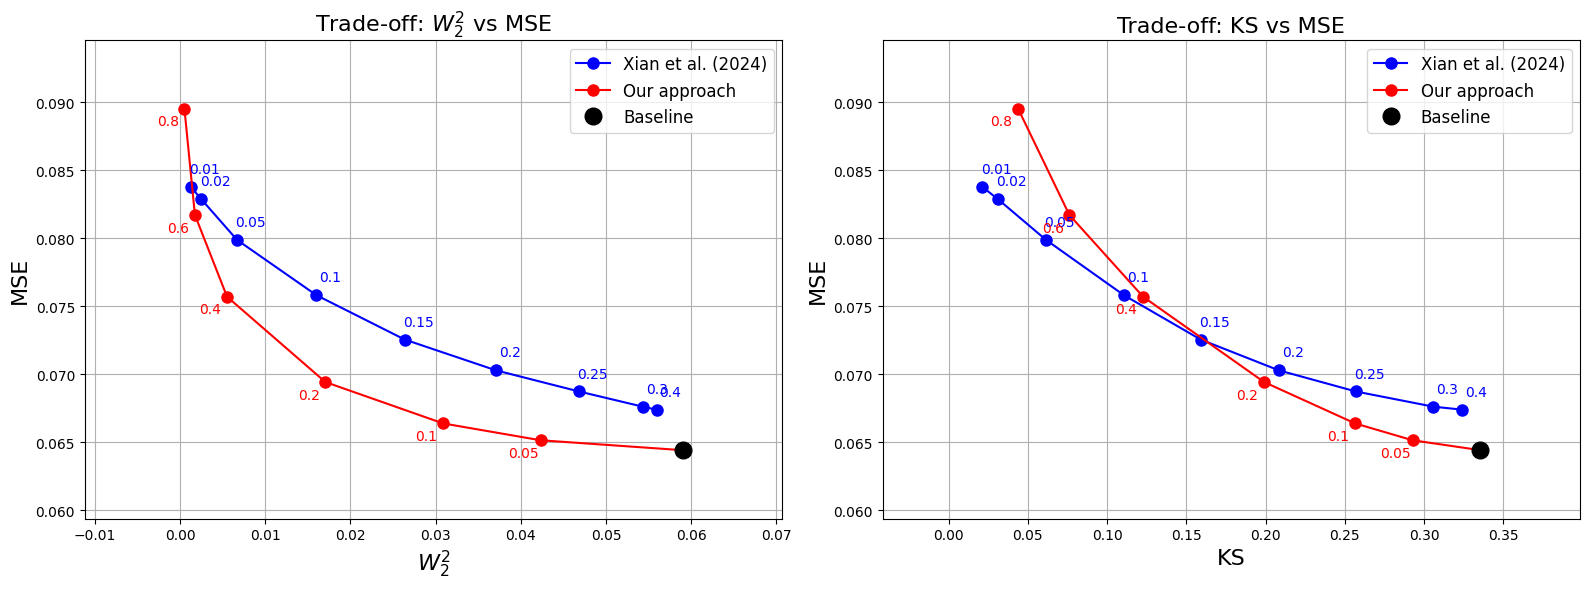

In [159]:
import matplotlib.pyplot as plt

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# -------------------------
# Left plot: W2 vs MSE
# -------------------------
ax = axes[0]

# Blue line for postprocessing (averaged)
ax.plot(av_w2_post, av_mse_post, '-o', color='blue', markersize=8, label='Xian et al. (2024)')
# Red line for our approach (averaged)
ax.plot(av_w2_in, av_mse_in, '-o', color='red', markersize=8, label='Our approach')
# Baseline first point
ax.plot(av_w2_in[0], av_mse_in[0], 'o', color='black', markersize=12, label='Baseline')

# Annotations
for g, xx, yy in zip(alpha_post, av_w2_post, av_mse_post):
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(10,10),
                ha='center', color='blue')
for i, (g, xx, yy) in enumerate(zip(alpha_in, av_w2_in, av_mse_in)):
    if i == 0:
        continue
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(-12,-12),
                ha='center', color='red')

ax.set_title(r"Trade-off: $W_2^2$ vs MSE", fontsize=16)
ax.set_xlabel(r"$W_2^2$", fontsize=16)
ax.set_ylabel("MSE", fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)
ax.margins(0.2, 0.2)

# -------------------------
# Right plot: KS vs MSE
# -------------------------
ax = axes[1]

# Blue line for postprocessing (averaged)
ax.plot(av_ks_post, av_mse_post, '-o', color='blue', markersize=8, label='Xian et al. (2024)')
# Red line for our approach (averaged)
ax.plot(av_ks_in, av_mse_in, '-o', color='red', markersize=8, label='Our approach')
# Baseline first point
ax.plot(av_ks_in[0], av_mse_in[0], 'o', color='black', markersize=12, label='Baseline')

# Annotations
for g, xx, yy in zip(alpha_post, av_ks_post, av_mse_post):
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(10,10),
                ha='center', color='blue')
for i, (g, xx, yy) in enumerate(zip(alpha_in, av_ks_in, av_mse_in)):
    if i == 0:
        continue
    ax.annotate(f"{g}", (xx, yy), textcoords="offset points", xytext=(-12,-12),
                ha='center', color='red')

ax.set_title("Trade-off: KS vs MSE", fontsize=16)
ax.set_xlabel("KS", fontsize=16)
ax.set_ylabel("MSE", fontsize=16)
ax.grid(True)
ax.legend(fontsize=12)
ax.margins(0.2, 0.2)

plt.tight_layout()
plt.savefig("result_seeds/tradeoffs_avg.pdf", dpi=300)
plt.savefig("result_seeds/tradeoffs_avg.svg", dpi=300)
plt.show()

